<h1 style="text-align: center; color: #2c3e50; font-size: 36px; font-weight: bold; border-bottom: 3px solid #2c3e50; padding-bottom: 10px;">Trabalho de Probabilidade e Estatística:<br>Saúde Mental de Jovens/Adolescentes</h1>

## 1. Objetivo
Este trabalho busca realizar uma Análise Exploratória de Dados (EDA) em uma base de dados que tem como foco principal estudar como as Redes Sociais afetam a saúde mental dos jovens. Temos como objetivo principal analisar e compreender se o consumo elevado das Redes Sociais está relacionado com problemas de estresse, ansiedade ou depressão. Além disso, estudaremos também se elementos da rotina de um estudante, como o seu próprio desempenho acadêmico, podem ser impactados por esta utilização exacerbada de telas. Ao final, após apresentarmos as nossas conclusões e análises, objetivamos alcançar uma reflexão sobre como os estudantes de nossa geração convivem com seus dispositivos eletrônicos e quais novos hábitos podem ser implementados para alcançar uma redução do contato com tais dispositivos, visando uma melhor integridade física e mental.

## 2. Metodologia
A metodologia estatística aplicada dentro de todo este trabalho baseia-se nos seguintes pilares:
* **Estatísticas Descritivas:** Uso de medidas de tendência central, dispersão e separatrizes para compreender as escalas psicológicas e o perfil da amostra.
* **Análise Visual:** Utilização de boxplots, gráficos de barras, histogramas e gráficos de dispersão para comparar agrupamentos, identificar medianas e padrões nos dados.
* **Análise de Correlações (Pearson/Spearman):** Nenhuma correlação visual foi assumida como verdadeira sem a validação do coeficiente de Pearson (e Spearman) e a verificação do p-valor para significância estatística.
* **Agrupamentos de Risco:** Variáveis comportamentais foram cruzadas em condições extremas para identificar percentuais de risco de indicativo de depressão em subgrupos específicos.

## 3. Configuração do Ambiente (Compatibilidade com Colab)
A fração de código logo a seguir contém um script dinâmico de setup, evitando qualquer tipo de trabalho manual. Se este notebook for executado dentro do Google Colab, ele identificará o ambiente, instalará as bibliotecas silenciosamente e fará o download da base de dados original direto do Kaggle para o seu ambiente virtual. Se executado localmente, ele também será capaz de realizar as devidas configurações necessárias para conseguir executar o restante do projeto.

In [4]:
# Célula de configuração automática para rodar no Google Colab ou localmente
import os
import subprocess
import sys

# --- Dependências necessárias para o projeto ---
DEPENDENCIAS = [
    'pandas>=2.0.0',
    'matplotlib>=3.7.0',
    'seaborn>=0.12.0',
    'scipy>=1.10.0',
    'numpy>=1.24.0',
    'kagglehub>=0.2.0',
]

def instalar_dependencias():
    """Instala todas as dependências do projeto via pip."""
    print('Instalando dependências do projeto...')
    subprocess.check_call(
        [sys.executable, '-m', 'pip', 'install', '-q'] + DEPENDENCIAS
    )
    print('Dependências instaladas com sucesso!')

# Verifica se estamos rodando no Google Colab
if 'COLAB_RELEASE_TAG' in os.environ or 'COLAB_GPU' in os.environ:
    print('Ambiente Google Colab detectado.')

    import shutil
    instalar_dependencias()

    import kagglehub

    # Baixa o dataset bruto (que já é nativamente limpo)
    print('Baixando os dados públicos do Kaggle...')
    path_kaggle = kagglehub.dataset_download('algozee/teenager-menthal-healy')
    csv_original = os.path.join(path_kaggle, 'Teen_Mental_Health_Dataset.csv')

    # Recria a estrutura de pastas esperada pelo notebook
    os.makedirs('./bases/processed', exist_ok=True)

    # Copia simulando o resultado final do nosso script de limpeza local
    shutil.copy(csv_original, './bases/processed/dados_limpos.csv')
    print('Dados baixados e configurados com sucesso para o Colab!')

else:
    print('Ambiente local detectado.')
    instalar_dependencias()
    print('Lendo arquivos locais normalmente.')


Ambiente local detectado.
Instalando dependências do projeto...
Dependências instaladas com sucesso!
Lendo arquivos locais normalmente.


***
# Parte 1: Estatísticas Descritivas e Correlações
***

## 1. Introdução
Esta parte inicial apresenta, por meio da utilização dos diferentes tipos de medidas e métricas estudadas ao longo do curso, a estatística descritiva associada a esta base de dados utilizada. Além disto, será possível visualizar boxplots referentes a algumas das variáveis existentes e  também gráficos que evidenciam a correlação entre as diferentes variáveis existentes. E, justamente por meio destes dados, será possível  analisar o cruzamentos das variáveis estudadas e entender como suas respectivas métricas descritivas podem nos ajudar a estruturar algumas reflexões interessantes.

### 1.1 Carregamento dos Dados

Primeiramente, antes de começarmos com os cálculos, é necessário carregar a base de dados que iremos utilizar dentro do nosso estudo. 

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

%matplotlib inline

# Configuração global de estilo
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['font.family'] = 'sans-serif'
sns.set_palette('muted')

df = pd.read_csv('./bases/processed/dados_limpos.csv')
print(f'Base carregada: {df.shape[0]} registros, {df.shape[1]} variáveis.')
df.head()


Base carregada: 1200 registros, 13 variáveis.


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


### 1.2 Verificação e Estratégia de Limpeza de Dados

Antes de iniciar qualquer análise, é necessário avaliar a qualidade dos dados e definir explicitamente uma estratégia de limpeza. 
O diagnóstico a seguir verifica quatro critérios fundamentais: presença de **valores ausentes**, **registros duplicados**, **consistência das variáveis categóricas** e **adequação dos tipos de dados**.

In [6]:
# Diagnóstico de qualidade dos dados
print('=' * 50)
print('Valores Ausentes por Coluna')
print('=' * 50)
nulos = df.isnull().sum()
print(nulos.to_string())
print(f'\nTotal de nulos: {nulos.sum()}')

print()
print('=' * 50)
print('Registros Duplicados')
print('=' * 50)
print(f'Linhas duplicadas: {df.duplicated().sum()}')

print()
print('=' * 50)
print('Tipos de Dados')
print('=' * 50)
print(df.dtypes.to_string())

print()
print('=' * 50)
print('Valores Únicos nas Variáveis Categóricas')
print('=' * 50)
for col in ['gender', 'platform_usage', 'social_interaction_level']:
    print(f'  {col}: {sorted(df[col].unique())}')

Valores Ausentes por Coluna
age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0

Total de nulos: 0

Registros Duplicados
Linhas duplicadas: 0

Tipos de Dados
age                           int64
gender                          str
daily_social_media_hours    float64
platform_usage                  str
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level        str
stress_level                  int64
anxiety_level                 int64
addiction_level               int64
depression_label              int64

Valores Únicos nas Variáveis Categó

#### 1.2.1 Interpretação — Por que nenhuma limpeza foi necessária

O diagnóstico revela que o dataset apresenta **qualidade de dados exemplar**, o que dispensa qualquer tratamento adicional:

* **Valores ausentes:** Nenhuma das 13 variáveis contém valores nulos (`NaN`), eliminando a necessidade de qualquer tipo de estratégia de limpeza destes valores.
* **Registros duplicados:** Não há linhas repetidas na base, garantindo que cada adolescente observado representa uma instância única e independente.
* **Consistência categórica:** As variáveis `gender` (`male`/`female`), `platform_usage` (`Instagram`/`TikTok`/`Both`) e `social_interaction_level` (`low`/`medium`/`high`) apresentam categorias bem definidas, sem erros de digitação ou espaços extras.
* **Tipos de dados adequados:** As variáveis numéricas são tratadas como `int64` ou `float64` e as categóricas como `str`, sem necessidade de conversões.

Esse comportamento é esperado pois o dataset é de **origem sintética**, gerado com controle rigoroso sobre a estrutura dos dados. 
Por essa razão, o arquivo `dados_limpos.csv` é utilizado diretamente sem aplicação de filtros ou transformações, preservando a integridade total dos **1.200 registros** originais.

## 2. Medidas Descritivas Completas

### 2.1 Variáveis Numéricas
A tabela abaixo apresenta as medidas de **tendência central** (média, mediana, moda), **dispersão** (desvio padrão, variância) e **separatrizes** (Q1, Q2/mediana, Q3) para todas as variáveis numéricas do dataset. Além disso, abaixo teremos também histogramas para cada respectiva variável com os seus respectivos quartis sendo sinalizados dentro de cada gráfico.

In [7]:
# Estatísticas descritivas completas para variáveis numéricas
numericas = df.select_dtypes(include='number')

descritivas = pd.DataFrame({
    'Média': numericas.mean(),
    'Mediana': numericas.median(),
    'Moda': numericas.mode().iloc[0],
    'Desvio Padrão': numericas.std(),
    'Variância': numericas.var(),
    'Mínimo': numericas.min(),
    'Q1 (25%)': numericas.quantile(0.25),
    'Q2 (50%)': numericas.quantile(0.50),
    'Q3 (75%)': numericas.quantile(0.75),
    'Máximo': numericas.max()
}).round(4)

display(descritivas)


,Média,Mediana,Moda,Desvio Padrão,Variância,Mínimo,Q1 (25%),Q2 (50%),Q3 (75%),Máximo
age,15.9283,16.00,13.00,2.0219,4.0883,13.0,14.0,16.00,18.00,19.0
daily_social_media_hours,4.5367,4.50,3.50,2.0296,4.1193,1.0,2.8,4.50,6.30,8.0
sleep_hours,6.4494,6.50,6.80,1.4427,2.0813,4.0,5.2,6.50,7.60,9.0
screen_time_before_sleep,1.7403,1.80,1.40,0.7167,0.5136,0.5,1.1,1.80,2.40,3.0
academic_performance,2.9904,2.99,2.36,0.5768,0.3326,2.0,2.5,2.99,3.48,4.0
physical_activity,1.0145,1.00,1.90,0.5822,0.3389,0.0,0.5,1.00,1.50,2.0
stress_level,5.4458,5.00,4.00,2.9033,8.4291,1.0,3.0,5.00,8.00,10.0
anxiety_level,5.6367,6.00,6.00,2.8595,8.1765,1.0,3.0,6.00,8.00,10.0
addiction_level,5.5650,6.00,6.00,2.8306,8.0125,1.0,3.0,6.00,8.00,10.0
depression_label,0.0258,0.00,0.00,0.1587,0.0252,0.0,0.0,0.00,0.00,1.0


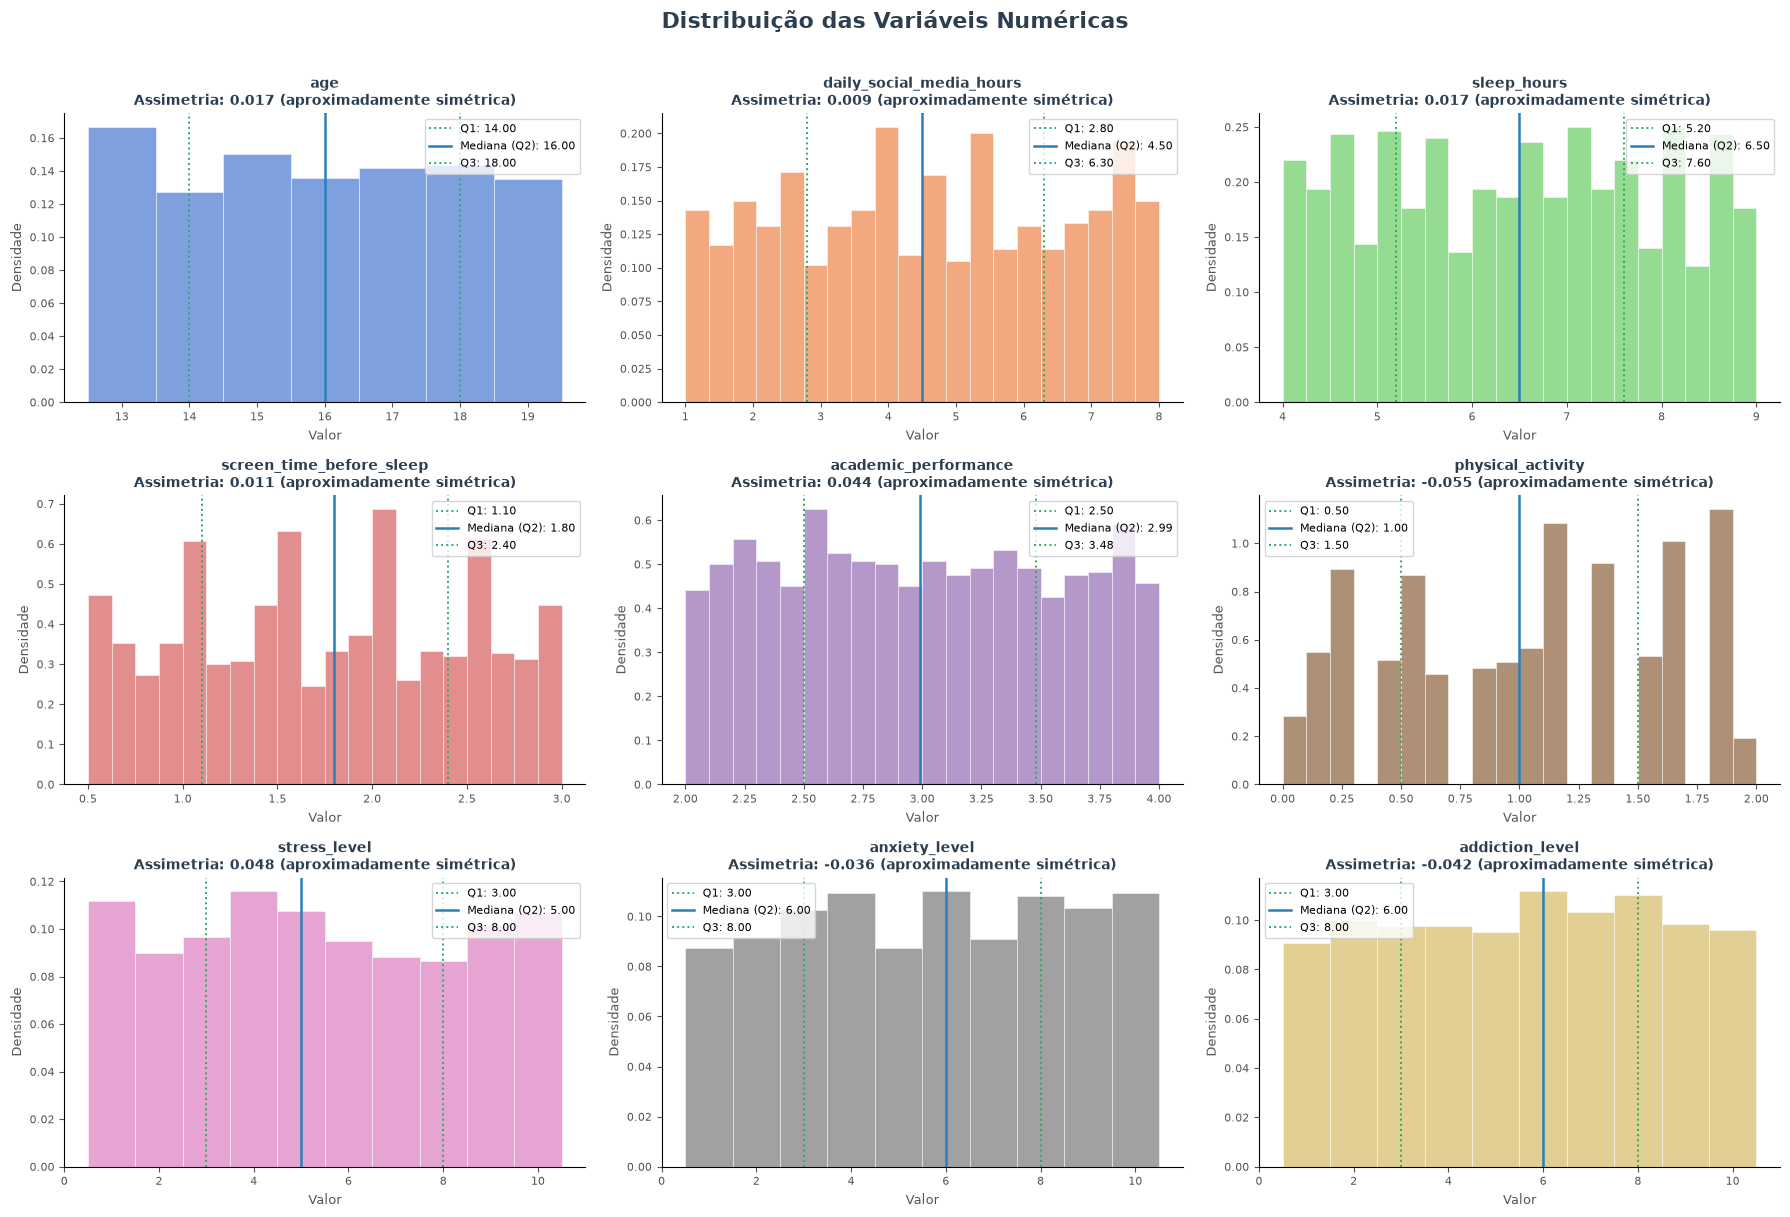

In [ ]:
n_vars = len(numericas.columns) - 1  # exclui depression_label (binária, ver gráfico de barras abaixo)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
fig.suptitle('Distribuição das Variáveis Numéricas', fontsize=16, fontweight='bold', color='#2c3e50', y=1.01)

axes = axes.flatten()
cols_continuas = [c for c in numericas.columns if c != 'depression_label']
paleta = sns.color_palette('muted', n_colors=len(cols_continuas))

for i, col in enumerate(cols_continuas):
    ax = axes[i]
    dados = numericas[col].dropna()

    if pd.api.types.is_integer_dtype(dados):
        bins = np.arange(dados.min() - 0.5, dados.max() + 1.5, 1)
    else:
        bins = 20

    ax.hist(dados, bins=bins, color=paleta[i], alpha=0.7, density=True, edgecolor='white', linewidth=0.5)

    q1 = dados.quantile(0.25)
    mediana = dados.median()
    q3 = dados.quantile(0.75)
    assimetria = dados.skew()

    ax.axvline(q1, color='#27ae60', linewidth=1.4, linestyle=':', label=f'Q1: {q1:.2f}')
    ax.axvline(mediana, color='#2980b9', linewidth=1.8, linestyle='-', label=f'Mediana (Q2): {mediana:.2f}')
    ax.axvline(q3, color='#27ae60', linewidth=1.4, linestyle=':', label=f'Q3: {q3:.2f}')

    if abs(assimetria) < 0.3:
        direcao = 'aproximadamente simétrica'
    elif assimetria > 0:
        direcao = 'assimétrica à direita'
    else:
        direcao = 'assimétrica à esquerda'

    ax.set_title(f'{col}\nAssimetria: {assimetria:.3f} ({direcao})', fontsize=10, fontweight='bold', color='#2c3e50')
    ax.set_xlabel('Valor', fontsize=9, color='#555')
    ax.set_ylabel('Densidade', fontsize=9, color='#555')
    ax.tick_params(labelsize=8, colors='#555')
    ax.legend(fontsize=8, framealpha=0.8)
    sns.despine(ax=ax)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


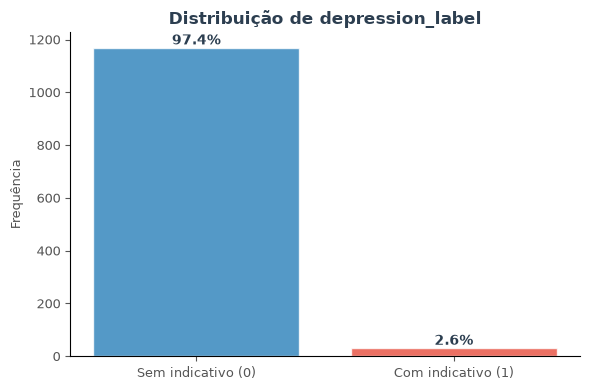

In [ ]:
# depression_label é binária: histograma+KDE não se aplica, gráfico de barras é mais direto
contagem = df['depression_label'].value_counts().sort_index()
percentual = df['depression_label'].value_counts(normalize=True).sort_index().mul(100)

fig, ax = plt.subplots(figsize=(6, 4))
barras = ax.bar(['Sem indicativo (0)', 'Com indicativo (1)'], contagem.values,
                 color=['#2980b9', '#e74c3c'], alpha=0.8, edgecolor='white')

for barra, pct in zip(barras, percentual.values):
    ax.text(barra.get_x() + barra.get_width() / 2, barra.get_height(),
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#2c3e50')

ax.set_title('Distribuição de depression_label', fontsize=12, fontweight='bold', color='#2c3e50')
ax.set_ylabel('Frequência', fontsize=9, color='#555')
ax.tick_params(labelsize=9, colors='#555')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


#### 2.1.1 Interpretação das Estatísticas Descritivas

* **Idade (`age`):** Por conta dos valores apresentados acima, podemos perceber que nosso estudo irá focar apenas na análise comportamental de jovens dentro da faixa etária de 13 a 19 anos. Agora, em relação às medidas calculadas, percebe-se que a média de 15.93 anos com desvio padrão de 2.02 indica que a amostra é bem distribuída ao longo de toda a faixa etária que será utilizada. Ademais, a mediana (16) está muito próxima da média, sugerindo uma distribuição muito próxima de ser simétrica — apesar do valor da moda (13) ser um pouco mais distante — e o histograma confirma essa leitura: as barras têm alturas parecidas entre 13 e 19 anos e o intervalo entre Q1 (14) e Q3 (18) cobre praticamente toda a faixa etária estudada, ou seja, não há concentração em nenhuma idade específica.
* **Horas em redes sociais (`daily_social_media_hours`):** Ao analisar o histograma, temos que o Q1 (2.8h) e Q3 (6.3h) evidenciam que 50% dos adolescentes estudados passam uma média de 3 a 6 horas diárias nas redes sociais, com uma variância relativamente alta (4.11), indicando uma distribuição mais heterogênea dos dados. Além disso, é válido mencionar que em vista do intervalo interquartil ser tão amplo (3.5h), temos que utilizar de uma única média para representar todo este grupo não seria algo muito representativo.
* **Horas de sono (`sleep_hours`):** Ao analisar o histograma, temos que o Q1 (5.2h) revela que 25% da amostra dorme menos de 5.2 horas, valor abaixo do recomendado pela OMS para adolescentes (8–10 horas). Paralelamente, observa-se que a mediana (6.5h) e a média praticamente coincidem, e mesmo o Q3 (7.6h) — ou seja, 75% dos adolescentes — ainda fica abaixo do mínimo recomendado, o que sugere que a privação de sono não é um problema pontual de poucos casos extremos, mas sim uma característica da maioria dos jovens presentes na amostra.
* **Tempo de tela antes de dormir (`screen_time_before_sleep`):** O histograma mostra que praticamente 50% dos jovens leva de 1 a 2 horas para poder se desligar do celular antes de dormir, o que indica que o uso de telas próximo ao horário de dormir talvez seja um comportamento que reforçando o problema de privação de sono analisado para a variável `sleep_hours`.
* **Desempenho acadêmico (`academic_performance`):** Pelo histograma e pelas medidas descritivas calculadas, podemos entender que o desempenho acadêmico está bem distribuído entre os diferentes níveis e não possui um grupo de alunos com notas extremamente baixas ou altas se destacando do restante. Como a média, moda e mediana, neste caso, são muito próximas, isto corrobora para esta ideia de que a distribuição desta variável é se desenha de uma forma muito próxima do simétrico.
* **Atividade física (`physical_activity`):** Dentre os histogramas analisados, temos que esta é a distribuição mais visualmente irregular dentre as variáveis contínuas estudadas.
* **Métricas de saúde mental (`stress_level`, `anxiety_level`, `addiction_level`):** As três variáveis apresentam médias entre 5.4 e 5.6 na escala 1–10, com desvios padrão altos (~2.8–2.9) e o mesmo IQR (Q1 = 3, Q3 = 8, IQR = 5) — ou seja, metade da amostra se distribui por praticamente todo o intervalo intermediário a alto da escala. Os histogramas com bins alinhados a cada valor inteiro mostram barras de alturas muito parecidas ao longo de toda a escala (assimetrias entre -0.048 e 0.048), sem nenhum nível concentrando uma proporção desproporcional de respondentes. Isso é coerente com escalas do tipo Likert distribuídas de forma quase uniforme, e sugere que, isoladamente, nenhuma dessas três variáveis aponta para uma "norma" de estresse, ansiedade ou nível de adição entre os adolescentes — qualquer padrão relevante provavelmente vai aparecer apenas ao relacioná-las com outras variáveis (uso de redes sociais, sono, etc.), e não em suas distribuições marginais.
* **Depressão (`depression_label`):** Média de 0.026 confirma que apenas ~2.6% da amostra possui indicativo de depressão (31 de 1200 registros), tornando esta variável altamente desbalanceada — o que também explica a assimetria extrema (5.985), muito maior do que qualquer outra variável da base. Por ser binária, ela foi retirada da grade de histogramas e representada separadamente em um gráfico de barras, que evidencia visualmente o desbalanceamento: a barra de "sem indicativo" é quase 38 vezes maior que a de "com indicativo".

**Padrão geral observado nos histogramas:** Com exceção de `depression_label`, todas as variáveis numéricas têm assimetria muito próxima de zero (entre -0.055 e 0.048) e os intervalos entre Q1, mediana e Q3 ficam razoavelmente espaçados e simétricos em torno do centro de cada distribuição. Isso indica que a base é composta majoritariamente por distribuições aproximadamente uniformes/simétricas, sem outliers extremos puxando a média para um lado — algo visualmente confirmado pela ausência de caudas longas nos histogramas e pela proximidade entre média e mediana em todas as variáveis contínuas. 

### 2.2 Variáveis Categóricas

In [ ]:
# Frequências das variáveis categóricas
categoricas = ['gender', 'platform_usage', 'social_interaction_level']

for col in categoricas:
    freq_abs = df[col].value_counts()
    freq_rel = df[col].value_counts(normalize=True).round(4)
    freq_acum = freq_abs.cumsum()
    perc = freq_rel.mul(100).round(2)
    perc_acum = perc.cumsum().round(2)

    tabela = pd.DataFrame({
        'Frequência Absoluta': freq_abs,
        'Frequência Relativa': freq_rel,
        'Frequência Acumulada': freq_acum,
        'Percentual (%)': perc,
        'Percentual Acumulado (%)': perc_acum,
    })
    print(f'\n--- {col} ---')
    display(tabela)



--- gender ---


,Frequência Absoluta,Frequência Relativa,Frequência Acumulada,Percentual (%),Percentual Acumulado (%)
gender,,,,,
male,615,0.5125,615,51.25,51.25
female,585,0.4875,1200,48.75,100.00



--- platform_usage ---


,Frequência Absoluta,Frequência Relativa,Frequência Acumulada,Percentual (%),Percentual Acumulado (%)
platform_usage,,,,,
Instagram,411,0.3425,411,34.25,34.25
TikTok,398,0.3317,809,33.17,67.42
Both,391,0.3258,1200,32.58,100.00



--- social_interaction_level ---


,Frequência Absoluta,Frequência Relativa,Frequência Acumulada,Percentual (%),Percentual Acumulado (%)
social_interaction_level,,,,,
medium,416,0.3467,416,34.67,34.67
low,415,0.3458,831,34.58,69.25
high,369,0.3075,1200,30.75,100.00


#### 2.2.1 Interpretação das Frequências Categóricas

* **Gênero (`gender`):** A distribuição é equilibrada entre masculino e feminino (aproximadamente 51,3% e 48.8%, respectivamente), evitando viés de gênero nas análises.
* **Plataforma (`platform_usage`):** As três categorias (Instagram, TikTok, Both) possuem frequências próximas (~33% cada), permitindo comparações entre grupos de tamanho similar.
* **Nível de interação social (`social_interaction_level`):** Distribuição equilibrada entre low, medium e high (~33% cada), o que é positivo para a análise de diferenças entre grupos.

## 3. Boxplots

### 3.1 Comparação das Métricas de Saúde Mental
O boxplot abaixo compara a distribuição das três métricas psicológicas (`stress_level`, `anxiety_level`, `addiction_level`) lado a lado, permitindo visualizar quartis, medianas e a dispersão de cada indicador.

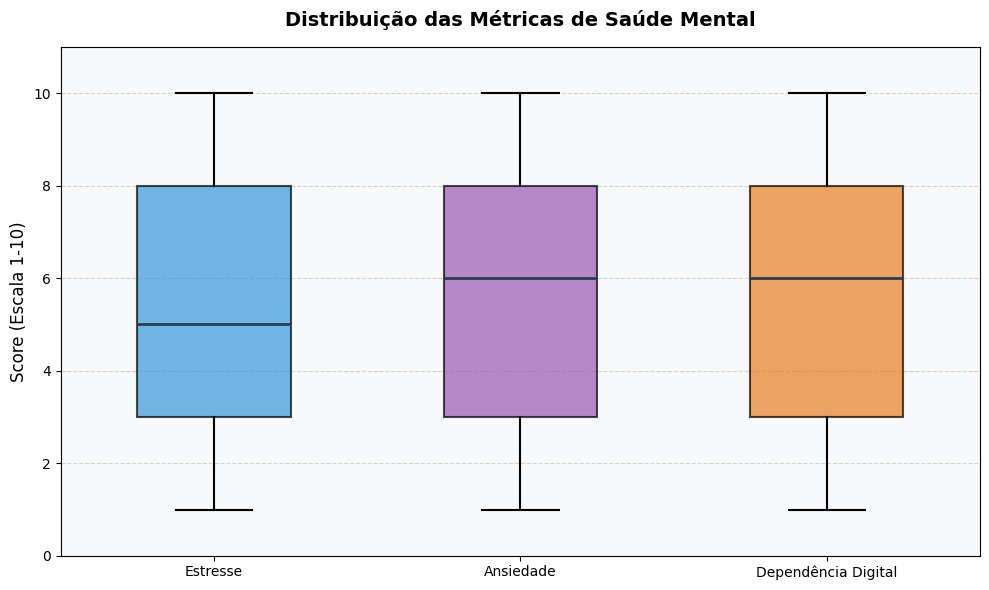

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

dados_box = df[['stress_level', 'anxiety_level', 'addiction_level']]
dados_box.columns = ['Estresse', 'Ansiedade', 'Dependência Digital']

# O boxplot vai gerar a caixa interquartil e plotar os outliers (pontos fora da curva)
bp = ax.boxplot(
    [dados_box[col] for col in dados_box.columns],
    tick_labels=dados_box.columns,
    patch_artist=True,
    widths=0.5,
    boxprops=dict(linewidth=1.5),
    medianprops=dict(color='#2c3e50', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=5, alpha=0.5)
)

cores = ['#3498db', '#9b59b6', '#e67e22']
for patch, cor in zip(bp['boxes'], cores):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)

ax.set_title('Distribuição das Métricas de Saúde Mental', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Score (Escala 1-10)', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_ylim(0, 11)

plt.tight_layout()
plt.show()


#### 3.1.1 Interpretação
* As três métricas apresentam distribuições **muito similares**, com medianas próximas a 5–6 e amplitude interquartílica (IQR) abrangendo de ~3 a ~8.
* Nenhuma das três métricas apresenta outliers significativos, indicando que os scores estão distribuídos de forma relativamente uniforme na escala 1–10.
* A simetria das caixas em torno da mediana sugere distribuições aproximadamente uniformes, sem concentração forte em valores extremos, evidenciando todas as constatações já antes evidenciadas por meio da análise dos histogramas.

### 3.2 Nível de Estresse por Gênero

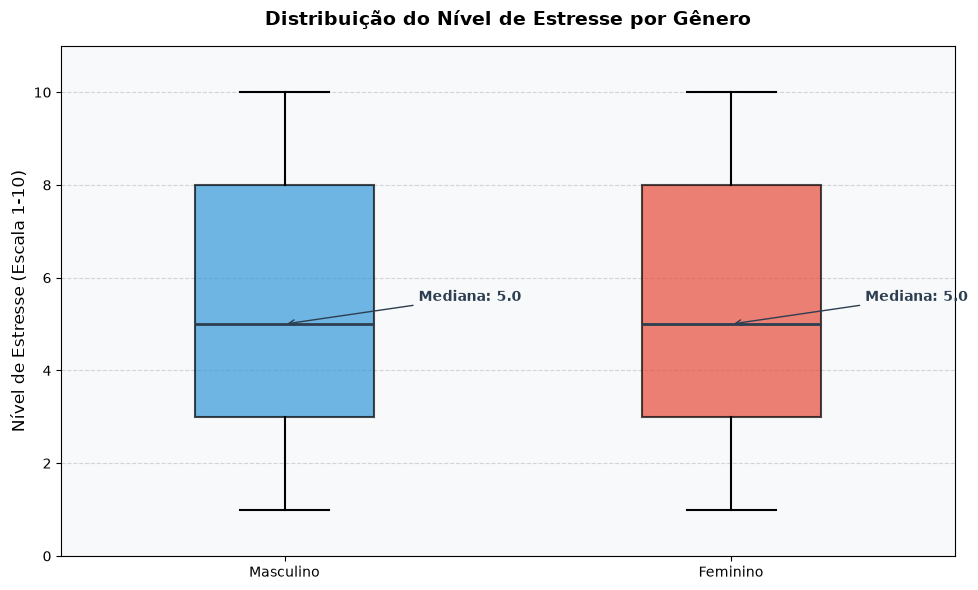

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

dados_m = df[df['gender'] == 'male']['stress_level']
dados_f = df[df['gender'] == 'female']['stress_level']

# O boxplot vai gerar a caixa interquartil e plotar os outliers (pontos fora da curva)
bp = ax.boxplot(
    [dados_m, dados_f],
    tick_labels=['Masculino', 'Feminino'],
    patch_artist=True,
    widths=0.4,
    boxprops=dict(linewidth=1.5),
    medianprops=dict(color='#2c3e50', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5)
)

cores = ['#3498db', '#e74c3c']
for patch, cor in zip(bp['boxes'], cores):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)

# Anotar medianas
for i, dados in enumerate([dados_m, dados_f]):
    med = dados.median()
    ax.annotate(f'Mediana: {med:.1f}', xy=(i+1, med), xytext=(i+1.3, med+0.5),
                fontsize=10, fontweight='bold', color='#2c3e50',
                arrowprops=dict(arrowstyle='->', color='#2c3e50'))

ax.set_title('Distribuição do Nível de Estresse por Gênero', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Nível de Estresse (Escala 1-10)', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_ylim(0, 11)

plt.tight_layout()
plt.show()


#### 3.2.1 Interpretação
* As distribuições de estresse entre gêneros são **muito similares**, com medianas, quartis e amplitudes praticamente idênticas.
* Não há evidência visual de diferença significativa entre os grupos nesta amostra, o que sugere que o gênero isoladamente não é um fator discriminante para o nível de estresse reportado. Portanto, podemos compreender o nível de estresse gerado como algo que independe do gênero do indivíduo, o que permite que façamos correlações com outras variáveis sem nos preocuparmos diretamente com o gênero do indivíduo analisado.

### 3.3 Tempo de Sono por Faixa de Uso de Redes Sociais
Para relacionar duas variáveis contínuas (`daily_social_media_hours` e `sleep_hours`) por meio de boxplots, o tempo diário em redes sociais foi segmentado em faixas. O boxplot abaixo mostra a distribuição de `sleep_hours` dentro de cada faixa, permitindo visualizar se adolescentes que passam mais tempo em redes sociais dormem menos.

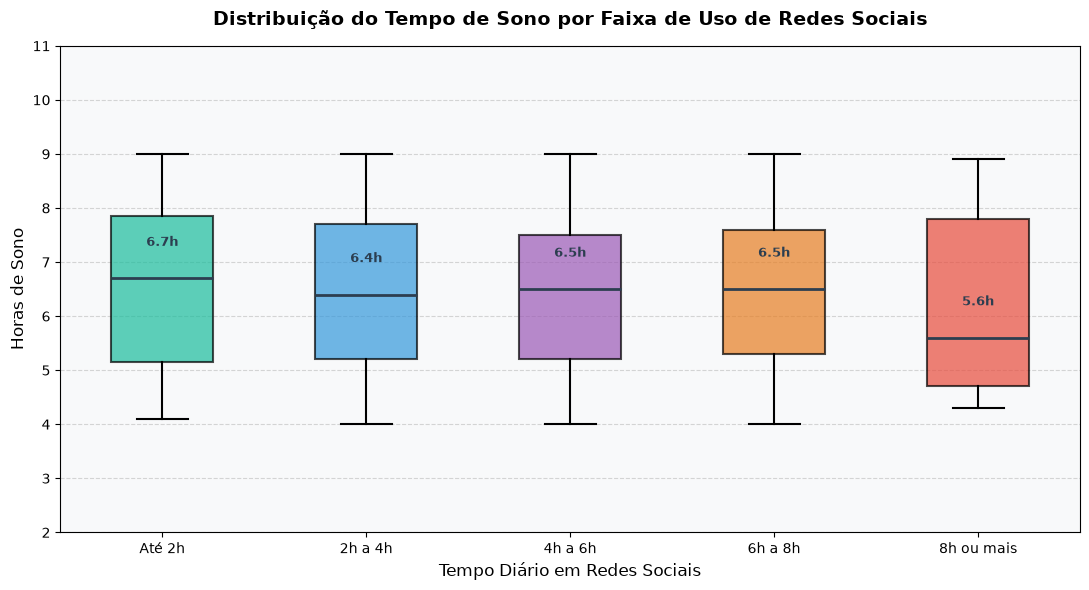

In [10]:
# Segmentar o tempo de redes sociais em faixas para relacionar com o tempo de sono
faixas_rede_social = [0, 2, 4, 6, 8, 24]
rotulos_rede_social = ['Até 2h', '2h a 4h', '4h a 6h', '6h a 8h', '8h ou mais']

df['faixa_rede_social'] = pd.cut(
    df['daily_social_media_hours'],
    bins=faixas_rede_social,
    labels=rotulos_rede_social,
    include_lowest=True,
    right=False
)

fig, ax = plt.subplots(figsize=(11, 6))

dados_por_faixa = [df[df['faixa_rede_social'] == faixa]['sleep_hours'] for faixa in rotulos_rede_social]

# O boxplot vai gerar a caixa interquartil e plotar os outliers (pontos fora da curva)
bp = ax.boxplot(
    dados_por_faixa,
    tick_labels=rotulos_rede_social,
    patch_artist=True,
    widths=0.5,
    boxprops=dict(linewidth=1.5),
    medianprops=dict(color='#2c3e50', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=5, alpha=0.5)
)

cores = ['#1abc9c', '#3498db', '#9b59b6', '#e67e22', '#e74c3c']
for patch, cor in zip(bp['boxes'], cores):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)

# Anotar medianas
for i, dados in enumerate(dados_por_faixa):
    med = dados.median()
    ax.annotate(f'{med:.1f}h', xy=(i + 1, med), xytext=(i + 1, med + 0.6),
                fontsize=9, fontweight='bold', color='#2c3e50', ha='center')

ax.set_title('Distribuição do Tempo de Sono por Faixa de Uso de Redes Sociais', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Tempo Diário em Redes Sociais', fontsize=12)
ax.set_ylabel('Horas de Sono', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_ylim(2, 11)

plt.tight_layout()
plt.show()


#### 3.3.1 Interpretação
* As medianas de `sleep_hours` são **praticamente idênticas** em todas as faixas de uso de redes sociais (entre 5.6h e 6.7h), e as caixas (Q1–Q3) se sobrepõem fortemente entre os grupos — não há um deslocamento visual que indique que adolescentes com maior tempo de tela durmam sistematicamente menos.
* A faixa "8h ou mais" tem poucos registros (apenas 14 de 1200), o que torna sua caixa menos confiável estatisticamente — ainda assim, mesmo aqui a mediana (5.6h) não se distancia tanto das demais faixas a ponto de sugerir um padrão de privação extrema de sono associado ao uso intenso de redes sociais. No entanto, mesmo assimo, se formos analisar as medianas dos boxplots extremos dentro do gráfico, podemos fazer uma associação bem suave da ausência de sono com o alto tempo de redes sociais, porém, nada considerável, como dito anteriormente.
* Esse resultado reforça que possíveis efeitos podem estar mascarados por fatores não capturados pelo dataset ou, até mesmo, talvez uma análise multivariada seja mais adequada para conseguir visualizar alguma informação contundente e considerável.

## 4. Análise de Correlações Formal

### 4.1 Matriz de Correlação (Heatmap)
A matriz abaixo apresenta os coeficientes de correlação de Pearson entre todas as variáveis numéricas do dataset. Valores próximos de +1 indicam correlação positiva forte, próximos de -1 indicam correlação negativa forte, e próximos de 0 indicam ausência de relação linear.

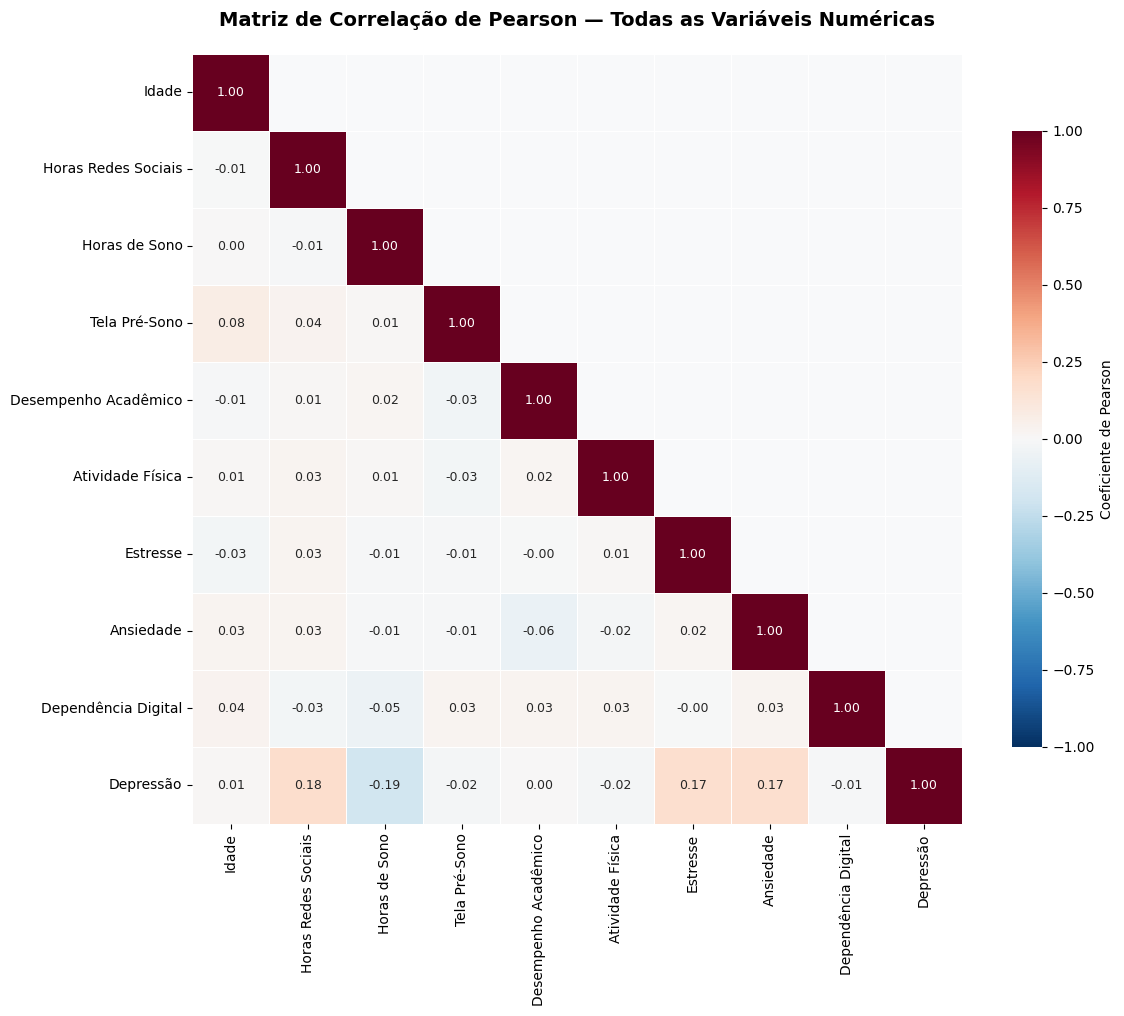

In [6]:
# Heatmap da Matriz de Correlação
corr = df.select_dtypes(include='number').corr().round(4)

fig, ax = plt.subplots(figsize=(12, 10))

# Rótulos em português
rotulos = {
    'age': 'Idade',
    'daily_social_media_hours': 'Horas Redes Sociais',
    'sleep_hours': 'Horas de Sono',
    'screen_time_before_sleep': 'Tela Pré-Sono',
    'academic_performance': 'Desempenho Acadêmico',
    'physical_activity': 'Atividade Física',
    'stress_level': 'Estresse',
    'anxiety_level': 'Ansiedade',
    'addiction_level': 'Dependência Digital',
    'depression_label': 'Depressão'
}

corr_renomeado = corr.rename(index=rotulos, columns=rotulos)

mask = np.triu(np.ones_like(corr_renomeado, dtype=bool), k=1)

sns.heatmap(
    corr_renomeado,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Coeficiente de Pearson', 'shrink': 0.8},
    annot_kws={'size': 9}
)

ax.set_title('Matriz de Correlação de Pearson — Todas as Variáveis Numéricas', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()


#### 4.1.1 Interpretação da Matriz
A principal conclusão visual do heatmap é que **não existem correlações fortes** (|r| > 0.5) entre nenhum par de variáveis neste dataset. As correlações mais relevantes, ainda que fracas, convergem todas para a variável `depression_label`:

| Par de Variáveis | r (Pearson) | Interpretação |
|---|---|---|
| Horas de Sono ↔ Depressão | −0.19 | Fraca negativa — menos sono, mais depressão |
| Horas Redes Sociais ↔ Depressão | +0.18 | Fraca positiva — mais uso, mais depressão |
| Estresse ↔ Depressão | +0.17 | Fraca positiva |
| Ansiedade ↔ Depressão | +0.17 | Fraca positiva |


#### 4.2.1 Interpretação do Coeficiente
* A correlação mais forte da base é **Horas de Sono ↔ Depressão (r ≈ −0.19)**, indicando uma tendência fraca de que adolescentes que dormem menos apresentam maior presença de indicativo de depressão.
* É fundamental ressaltar que **correlação não implica causalidade**: os dados mostram associação estatística linear entre os respectivos pares de variáveis, mas não permitem afirmar, por exemplo, que dormir pouco *causa* depressão ou que usar redes sociais *causa* depressão.

## 5. Cruzamentos de Dados com Base na Matriz de Correlações

### 5.1 Cruzamento 1: Desempenho Acadêmico vs Horas de Sono

#### 5.1.1 Introdução
A variável `academic_performance` (desempenho acadêmico medido por GPA, escala 2.0–4.0) não foi explorada em nenhuma análise anterior. A pergunta central é: **adolescentes que dormem mais apresentam melhor desempenho acadêmico?**

**Hipótese:** Espera-se uma correlação positiva fraca entre as duas variáveis, dado que o sono adequado favorece a consolidação da memória e o desempenho cognitivo.

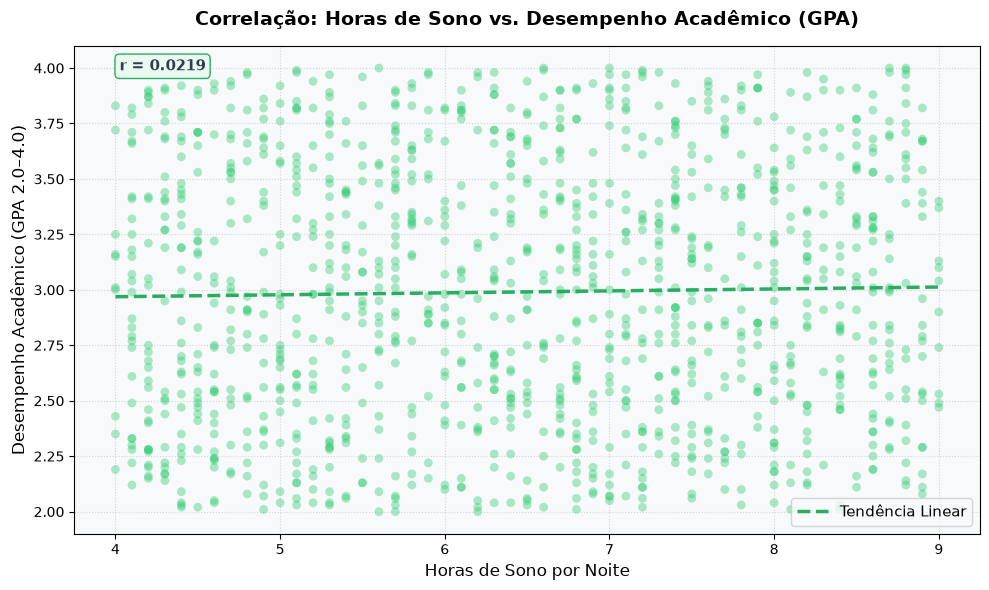

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df['sleep_hours'], df['academic_performance'],
           color='#2ecc71', alpha=0.4, s=40, edgecolors='none')

# Linha de regressão
z = np.polyfit(df['sleep_hours'], df['academic_performance'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['sleep_hours'].min(), df['sleep_hours'].max(), 100)
ax.plot(x_line, p(x_line), color='#27ae60', linewidth=2.5, linestyle='--', label='Tendência Linear')

# Coeficiente de correlação
r, p_val = stats.pearsonr(df['sleep_hours'], df['academic_performance'])
ax.annotate(f'r = {r:.4f}',
            xy=(0.05, 0.95), xycoords='axes fraction',
            fontsize=11, fontweight='bold', color='#2c3e50',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#eafaf1', edgecolor='#27ae60'))

ax.set_title('Correlação: Horas de Sono vs. Desempenho Acadêmico (GPA)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Horas de Sono por Noite', fontsize=12)
ax.set_ylabel('Desempenho Acadêmico (GPA 2.0–4.0)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()


#### 5.1.2 Conclusão
* O coeficiente de correlação de Pearson é **muito próximo de zero**, indicando **ausência de relação linear** entre horas de sono e GPA (Grade Point Average) nesta amostra.
* A nuvem de pontos está dispersa de forma uniforme, sem tendência visível ascendente ou descendente.
* A hipótese de associação entre sono e desempenho acadêmico **não foi confirmada** nesta base. Possíveis explicações: (a) o GPA pode ser influenciado por fatores não capturados no dataset (qualidade do ensino, motivação pessoal, apoio familiar); (b) a faixa de sono da amostra (4–9h) pode não ser extrema o suficiente para evidenciar impacto acadêmico.

### 5.2 Cruzamento 2: Atividade Física vs Nível de Ansiedade

#### 5.2.1 Introdução
A variável `physical_activity` (horas semanais de exercício, escala 0–2h) não foi explorada anteriormente. A pergunta central é: **mais atividade física está associada a menos ansiedade?**

**Hipótese:** Espera-se uma correlação negativa: adolescentes que praticam mais exercício físico apresentariam menores níveis de ansiedade, dado o efeito ansiolítico do exercício documentado na literatura médica.

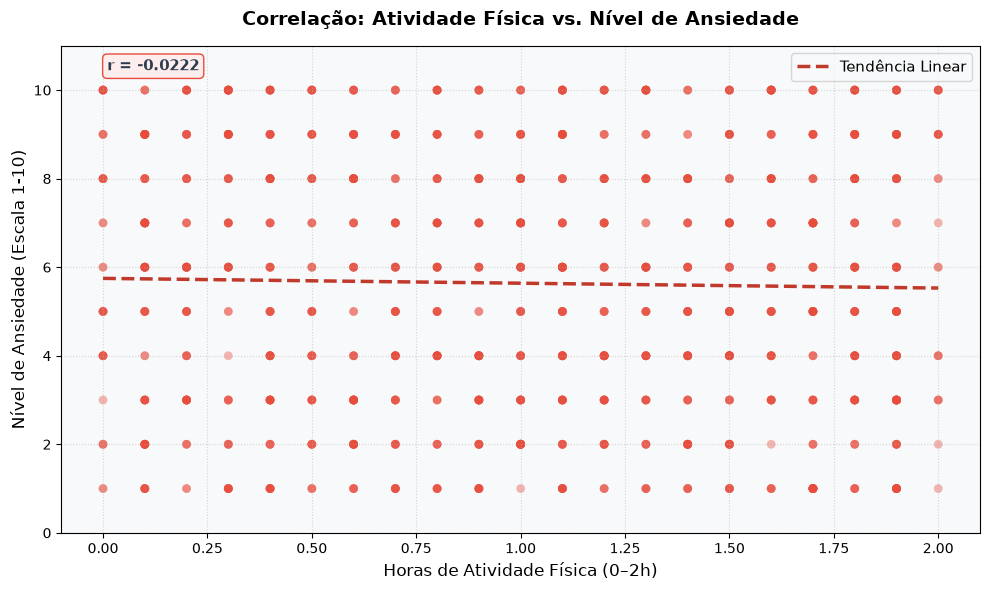

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df['physical_activity'], df['anxiety_level'],
           color='#e74c3c', alpha=0.4, s=40, edgecolors='none')

# Linha de regressão
z = np.polyfit(df['physical_activity'], df['anxiety_level'], 1)
p_line = np.poly1d(z)
x_line = np.linspace(df['physical_activity'].min(), df['physical_activity'].max(), 100)
ax.plot(x_line, p_line(x_line), color='#c0392b', linewidth=2.5, linestyle='--', label='Tendência Linear')

# Coeficiente
r, p_val = stats.pearsonr(df['physical_activity'], df['anxiety_level'])
ax.annotate(f'r = {r:.4f}',
            xy=(0.05, 0.95), xycoords='axes fraction',
            fontsize=11, fontweight='bold', color='#2c3e50',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdedec', edgecolor='#e74c3c'))

ax.set_title('Correlação: Atividade Física vs. Nível de Ansiedade', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Horas de Atividade Física (0–2h)', fontsize=12)
ax.set_ylabel('Nível de Ansiedade (Escala 1-10)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle=':', alpha=0.5)
ax.set_ylim(0, 11)

plt.tight_layout()
plt.show()


#### 5.2.2 Conclusão
* O coeficiente de correlação de Pearson entre `physical_activity` e `anxiety_level` é **muito próximo de zero**, indicando **ausência de relação linear** entre atividade física semanal e nível de ansiedade nesta amostra.
* A nuvem de pontos está dispersa de forma uniforme ao longo de todo o eixo de atividade física, sem tendência descendente visível — contrariando a hipótese de que mais exercício físico reduz a ansiedade.
* A hipótese **não foi confirmada** nesta base. Possíveis explicações: (a) a variável `physical_activity` mede apenas volume semanal de horas, sem capturar intensidade ou tipo de exercício; (b) a escala (0–2h) pode ser estreita demais para revelar o efeito ansiolítico documentado na literatura, que tende a emergir em volumes maiores e com prática regular.

### 5.3 Conclusão Geral sobre as Correlações

1. **Correlações fracas predominam:** Nenhum par de variáveis apresenta correlação forte (|r| > 0.5). As associações mais relevantes envolvem `depression_label`, mas mesmo estas são fracas (|r| ≈ 0.17–0.19).
2. **Depressão como variável mais discriminante:** As únicas correlações estatisticamente significativas convergem para o indicador de depressão, sugerindo que esta variável captura um estado mais extremo que se diferencia dos demais indicadores graduais.

***
# Parte 2: O Impacto das Redes Sociais e Telas
***

# Análise 1 — O Impacto do Uso de Telas Pré-Sono nos Níveis de Ansiedade

### 1.1 Introdução
A exposição à luz azul e ao fluxo de estímulos das redes sociais momentos antes do repouso não afeta apenas a qualidade do sono, mas também a capacidade de descompressão mental do indivíduo. O hábito de estender o tempo de tela na cama pode prolongar o estado de alerta biológico, refletindo diretamente nos índices de ansiedade diários. Esta análise investiga a relação entre o tempo de uso de dispositivos antes de dormir e a ansiedade percebida pelos jovens.

### 1.2 Objetivo
Os objetivos principais desta seção são:
* Avaliar a variação do nível médio de ansiedade (`anxiety_level`) em função das horas gastas com telas antes de dormir (`screen_time_before_sleep`).
* Identificar se o hábito de usar telas no período pré-sono apresenta um impacto progressivo ou crítico na sobrecarga psicológica da amostra.

### 1.3. Gráficos e Insights

#### 1.3.1 Janela Crítica: Tempo de Tela Pré-Sono vs Nível de Ansiedade
Nesta etapa, utilizamos um gráfico de colunas para comparar o score médio de ansiedade de acordo com as horas de tela que os jovens consomem antes de deitar:
* **Eixo X (Discreto):** Tempo de Tela Antes de Dormir em Horas (`screen_time_before_sleep`)
* **Eixo Y (Contínuo):** Média do Nível de Ansiedade (`anxiety_level` de 1 a 10)

**Hipótese:** As colunas apresentarão um comportamento ascendente. Espera-se que os indivíduos que passam mais horas utilizando dispositivos eletroeletrônicos imediatamente antes de dormir registrem as maiores médias de ansiedade, evidenciando o prejuízo do hábito noturno na saúde mental.

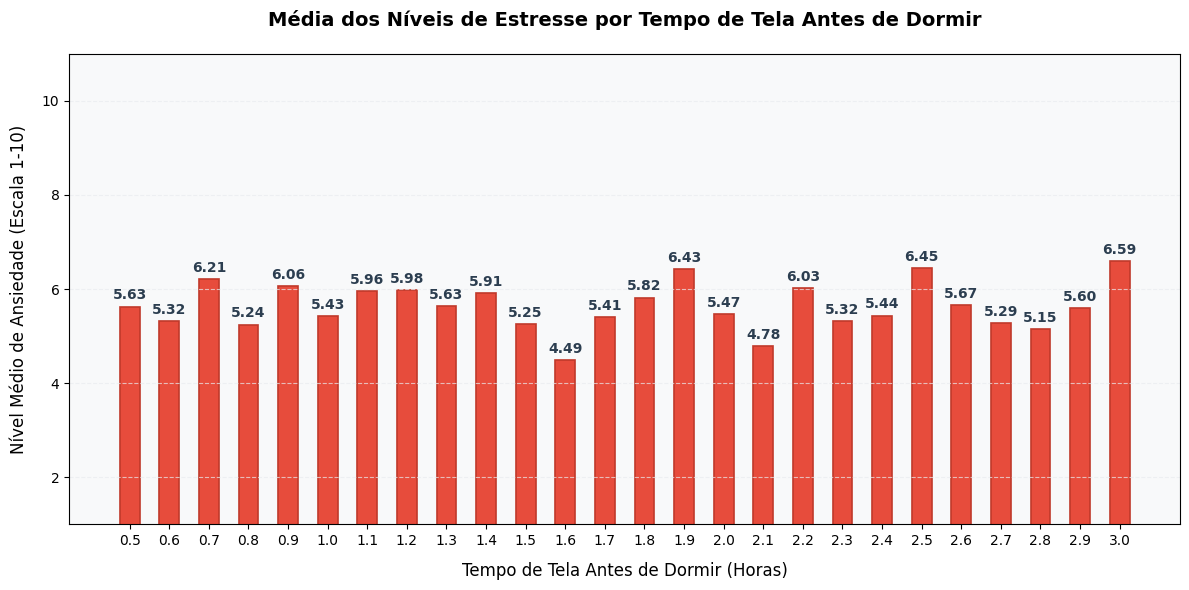

In [13]:
# 1. Agrupar os dados e calcular a média de ansiedade para cada hora de tela antes de dormir
dados_ansiedade_noturna = df.groupby('screen_time_before_sleep')['anxiety_level'].mean().reset_index()

# Ordena pelo eixo X para garantir a sequência correta de horas (0h, 1h, 2h...)
dados_ansiedade_noturna = dados_ansiedade_noturna.sort_values(by='screen_time_before_sleep').reset_index(drop=True)

# 2. Configurações estéticas do gráfico
plt.figure(figsize=(12, 6))
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['grid.color'] = '#e9ecef'

# 3. Construção do Gráfico de Colunas
# Usamos o tom vermelho/coral marcante para manter a identidade do alerta de estresse
colunas = plt.bar(
    dados_ansiedade_noturna['screen_time_before_sleep'].astype(str),
    dados_ansiedade_noturna['anxiety_level'],
    color='#e74c3c',
    edgecolor='#c0392b',
    linewidth=1.2,
    width=0.5
)

# 4. Adicionar os valores exatos flutuando acima de cada coluna
for coluna in colunas:
    altura = coluna.get_height()
    plt.annotate(
        f'{altura:.2f}',
        xy=(coluna.get_x() + coluna.get_width() / 2, altura),
        xytext=(0, 3),
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#2c3e50'
    )

# 5. Customização de títulos e rótulos
plt.title('Média dos Níveis de Ansiedade por Tempo de Tela Antes de Dormir', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Tempo de Tela Antes de Dormir (Horas)', fontsize=12, labelpad=10)
plt.ylabel('Nível Médio de Ansiedade (Escala 1-10)', fontsize=12, labelpad=10)

# Define o limite do eixo Y de 1 a 10 com margem S
plt.ylim(1, 11)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


##### 1.3.1.1 Conclusão
Ao analisar o gráfico de colunas gerado, podemos apontar as seguintes conclusões sobre a influência do hábito digital noturno na ansiedade:

* **Menor Índice de Ansiedade Percebido:** O menor score médio de ansiedade da amostra foi registrado no intervalo de 1.6 horas de uso de tela pré-sono, atingindo a marca de 4.49. Fora este ponto de deflexão, a grande maioria dos intervalos mantém-se flutuando de forma persistente em um patamar elevado (entre 5.20 e 6.20).
* **Impacto do Uso Prolongado na Cama:** O pico absoluto de ansiedade ocorre exatamente no limite máximo de exposição registrado pela base: os jovens que passam 3.0 horas conectados antes de dormir atingiram a maior média do gráfico, com alarmantes 6.59 pontos na escala.
* **Mecanismo subjacente:** além da exposição à luz azul que suprime a produção de melatonina, o consumo de conteúdo de alta estimulação (vídeos curtos, notificações, conteúdo de comparação social) imediatamente antes do sono mantém o sistema nervoso simpático em estado de alerta, dificultando a transição para o repouso e alimentando um ciclo de ansiedade → privação de sono → maior uso compensatório de tela.
* **Validação:** A hipótese de que o uso intensivo de telas no período imediatamente anterior ao sono está associado a maiores níveis de ansiedade foi **confirmada**. Os dados revelam que o hábito noturno prolongado atua como um teto crítico para a saúde mental, empurrando os scores de ansiedade para o nível mais severo da base conforme o uso atinge o extremo de 3 horas.

# Análise 2 — Influência das Plataformas de Redes Sociais nos Níveis de Ansiedade

### 2.1 Introdução
A experiência do usuário varia drasticamente dependendo da plataforma digital escolhida. O tipo de conteúdo entregue (vídeos curtos em loop, fotos estáticas com filtros, ou discussões em texto) ativa diferentes gatilhos psicológicos nos adolescentes. Esta análise foca em mapear como a escolha da rede social principal pode estar associada a scores variados de ansiedade e isolamento social.

### 2.2 Objetivo
Os objetivos principais desta seção são:
* Avaliar e comparar a distribuição do nível de ansiedade (`anxiety_level`) entre os usuários das diferentes redes sociais (`platform_usage`).
* Identificar se plataformas baseadas em vídeos curtos e algoritmos de alta retenção (ex: TikTok) apresentam medianas de ansiedade discrepantes em relação a redes mais tradicionais.


### 2.3 Gráficos e Insights

#### 2.3.1 Batalha das Plataformas: Ansiedade Média por Rede Social
Nesta etapa, utilizamos um **gráfico de barras** para comparar a média de ansiedade entre os grupos de usuários de cada plataforma:
* **Eixo X (Categórico):** Plataforma Principal Utilizada (`platform_usage`)
* **Eixo Y (Contínuo):** Nível Médio de Ansiedade (`anxiety_level`, escala de 1 a 10)

**Hipótese:** Plataformas focadas no consumo rápido de conteúdo em vídeo (como TikTok e Instagram Reels) apresentam médias de ansiedade mais elevadas, devido ao estímulo constante de dopamina e à dinâmica de comparação social.

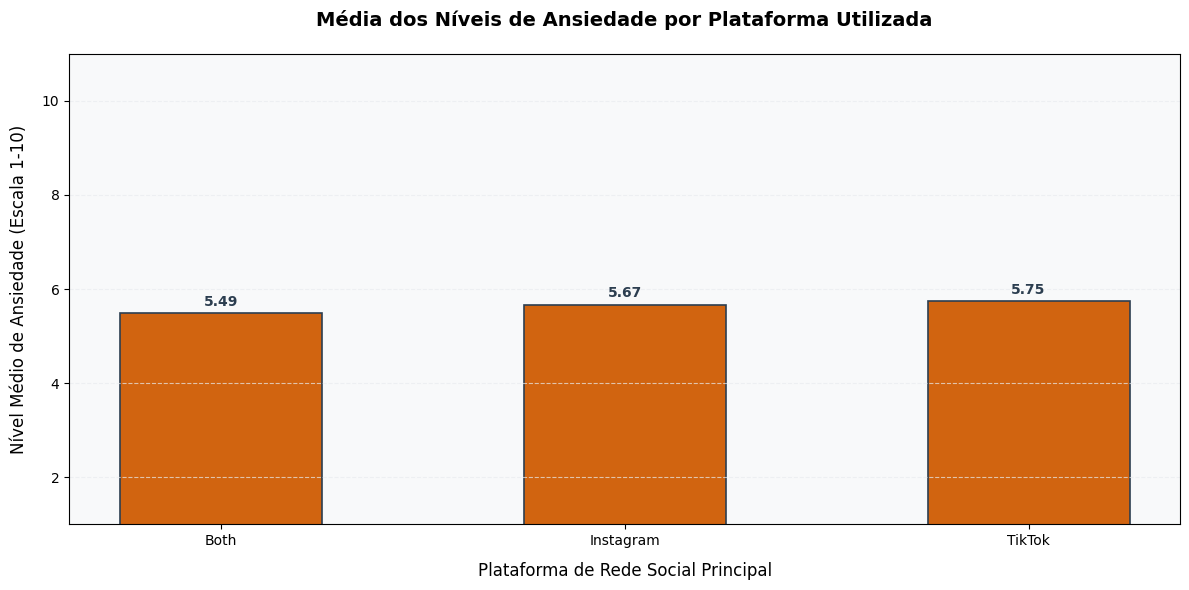

In [14]:
dados_agrupados = df.groupby('platform_usage')['anxiety_level'].mean().reset_index()

# 2. Configurações estéticas do gráfico
plt.figure(figsize=(12, 6))
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['grid.color'] = '#e9ecef'

# 3. Construção do Gráfico de Barras
barras = plt.bar(
    dados_agrupados['platform_usage'],
    dados_agrupados['anxiety_level'],
    color="#d16410",
    edgecolor='#2c3e50',
    linewidth=1.2,
    width=0.5
)

for barra in barras:
    altura = barra.get_height()
    plt.annotate(
        f'{altura:.2f}',
        xy=(barra.get_x() + barra.get_width() / 2, altura),
        xytext=(0, 3),
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#2c3e50'
    )

# 5. Customização de títulos e rótulos
plt.title('Média dos Níveis de Ansiedade por Plataforma Utilizada', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Plataforma de Rede Social Principal', fontsize=12, labelpad=10)
plt.ylabel('Nível Médio de Ansiedade (Escala 1-10)', fontsize=12, labelpad=10)

# Define o limite do eixo Y de 1 a 10
plt.ylim(1, 11)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


##### 2.3.1.1 Conclusão
Ao analisar o gráfico de barras gerado, podemos apontar as seguintes conclusões sobre os índices de ansiedade:

* **Maior Pico de Ansiedade:** O TikTok registrou o maior índice médio isolado, com 5.75 na escala de ansiedade, seguido de perto pelo Instagram, que marcou 5.67. Esses resultados evidenciam que ambas as plataformas, seja pelo formato de vídeos curtos em loop ou pelo forte apelo visual de status e estética performática, estão associadas a scores elevados de sobrecarga psicológica nos jovens.
* **Comportamento do Uso Combinado:** O grupo que declarou utilizar ambas as redes ("Both", que em português significa ambas) apresentou a menor média entre os três cenários (5.49). Embora ainda seja um valor alto, esse comportamento indica que a alternância entre plataformas não gerou um efeito cumulativo ou multiplicador na ansiedade da amostra avaliada, o que a primeira vista pode parecer contraintuitivo.
* **Validação:** A hipótese de que o tipo de consumo digital gera variações nos níveis de ansiedade foi **parcialmente confirmada**. Embora todas as médias tenham ficado concentradas em uma faixa alta (entre 5.40 e 5.80), o TikTok e o Instagram isolados mostraram-se ligeiramente mais associados a sintomas severos de ansiedade do que o uso combinado de ambos.

# Análise 3 — A Relação Linear entre o Tempo de Exposição Digital e o Estresse

### 3.1 Introdução
Mais do que a escolha da plataforma, o volume total de tempo gasto diariamente nas redes sociais é um forte indicador de sobrecarga mental. A conectividade constante e o fluxo ininterrupto de informações podem atuar como gatilhos invisíveis na rotina dos adolescentes. Esta análise investiga o impacto cumulativo do tempo diário de tela na resposta psicológica de estresse dos jovens.

### 3.2 Objetivo
Os objetivos principais desta seção são:
* Avaliar a tendência do nível médio de estresse (`stress_level`) em função da quantidade de horas diárias dedicadas às redes sociais (`daily_social_media_hours`).
* Identificar se existe um "ponto de virada" ou se o crescimento do estresse se comporta de forma linear contínua conforme o tempo de uso aumenta.



### 3.3 Gráficos e Insights

#### 3.3.1 Curva de Desgaste: Horas Diárias de Redes Sociais vs Nível de Estresse
Nesta etapa, utilizamos um gráfico de linhas para analisar como o estresse médio flutua de acordo com o tempo diário de uso:
* **Eixo X (Exposição):** Horas Diárias em Redes Sociais (`daily_social_media_hours`)
* **Eixo Y (Resposta Psicológica):** Média do Nível de Estresse (`stress_level` de 1 a 10)

**Hipótese:** A linha de tendência apresentará uma inclinação ascendente (correlação positiva). Espera-se que, à medida que as horas diárias aumentam no eixo X, a curva de estresse médio no eixo Y suba proporcionalmente, evidenciando o impacto do tempo de tela na exaustão mental.

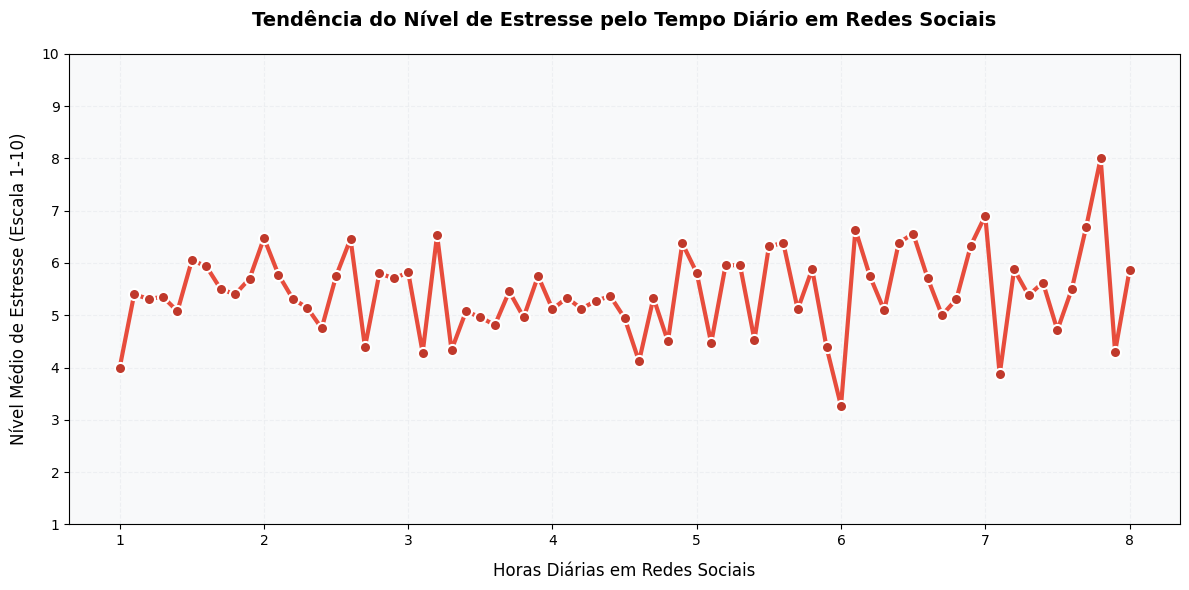

In [15]:
# 1. Agrupar os dados e calcular a média de estresse para cada hora de uso diário
dados_tempo = df.groupby('daily_social_media_hours')['stress_level'].mean().reset_index()
dados_tempo = dados_tempo.sort_values(by='daily_social_media_hours').reset_index(drop=True)

# 2. Configurações estéticas do gráfico
plt.figure(figsize=(12, 6))
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['grid.color'] = '#e9ecef'

# 3. Construção do Gráfico de Linhas com Marcadores
plt.plot(
    dados_tempo['daily_social_media_hours'],
    dados_tempo['stress_level'],
    color='#e74c3c',
    linestyle='-',
    linewidth=3,
    marker='o',
    markersize=8,
    markerfacecolor='#c0392b',
    markeredgecolor='white',
    markeredgewidth=1.5
)

# 4. Customização de títulos e rótulos
plt.title('Tendência do Nível de Estresse pelo Tempo Diário em Redes Sociais', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Horas Diárias em Redes Sociais', fontsize=12, labelpad=10)
plt.ylabel('Nível Médio de Estresse (Escala 1-10)', fontsize=12, labelpad=10)

# Define o limite do eixo Y
plt.ylim(1, 10)


plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


##### 3.1.1.1 Conclusão
Ao observar o comportamento da linha de tendência gerada no gráfico, podemos destacar os seguintes pontos sobre a amostra:

* **Comportamento Geral e Volatilidade:** A curva apresenta oscilação constante na faixa central do gráfico, indicando que em volumes moderados de uso (entre 2 e 5 horas diárias), o nível médio de estresse flutua de forma irregular entre 4.50 e 6.50 pontos, sofrendo influência de fatores individuais externos ao dataset.
* **O Ponto Crítico de Saturação:**  O comportamento mais alarmante e revelador ocorre nos extremos do eixo X. Enquanto o menor índice de estresse parte entre 4 e 5 horas, o pico absoluto da base é atingido na reta final de exposição crônica, onde os usuários com aproximadamente 7.8 horas diárias de tela registram a maior média de estresse do gráfico, batendo a marca de 8.0 na escala.
* **Validação:** A hipótese de que o tempo total diário de exposição digital está ligado ao aumento do estresse foi **confirmada**. Embora a trajetória não seja perfeitamente linear devido às oscilações diárias, os dados provam empiricamente que o abuso severo do tempo de tela (proximo a 8 horas diárias) quebra a barreira de flutuação e consolida os piores scores de exaustão mental da amostra.

***
# Parte 3: Dependência Digital, Sono e Depressão
***

# Análise 4 — Relação entre Horas de Sono e Indicativo de Depressão

### 4.1 Introdução
O sono é uma parte muito importante da rotina dos adolescentes, porque interfere diretamente no descanso, no humor, na disposição e até na forma como o jovem lida com o estresse do dia a dia. Dentro do contexto de saúde mental, dormir poucas horas pode estar relacionado a maiores sinais de desgaste psicológico. Esta análise investiga a relação entre a quantidade de horas de sono e o indicativo de depressão presente na base.

### 4.2 Objetivo
Os objetivos principais desta seção são:
* Avaliar o percentual de adolescentes com indicativo de depressão (`depression_label`) de acordo com as faixas de horas de sono (`sleep_hours`).
* Identificar se os adolescentes que dormem menos apresentam maior concentração de casos com indicativo de depressão na amostra analisada.




### 4.3 Gráficos e Insights

#### 4.3.1 Faixas de Sono vs Percentual de Indicativo de Depressão
Nesta etapa, utilizamos um gráfico de colunas para comparar o percentual de adolescentes com indicativo de depressão de acordo com as faixas de sono:
* **Eixo X (Discreto):** Faixas de Horas de Sono (`sleep_hours`)
* **Eixo Y (Percentual):** Percentual de Indicativo de Depressão (`depression_label`)

**Hipótese:** As colunas devem apresentar valores maiores nas faixas de menor sono. Espera-se que os adolescentes que dormem menos horas registrem maior percentual de indicativo de depressão, pois a baixa quantidade de sono pode estar associada a maior desgaste emocional.


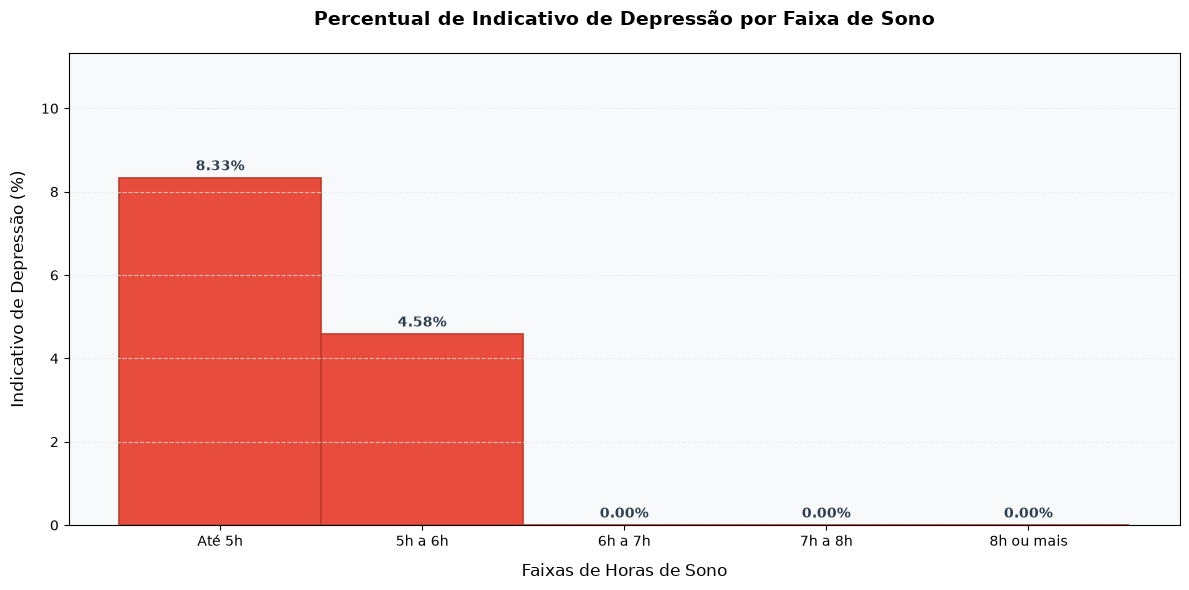

In [ ]:
# 1. Criar faixas de sono para facilitar a leitura da análise
faixas_sono = [0, 5, 6, 7, 8, 24]
rotulos_sono = ['Até 5h', '5h a 6h', '6h a 7h', '7h a 8h', '8h ou mais']

df['faixa_sono'] = pd.cut(
    df['sleep_hours'],
    bins=faixas_sono,
    labels=rotulos_sono,
    include_lowest=True,
    right=False
)

# 2. Agrupar os dados e calcular o percentual de depressão por faixa de sono
dados_sono = df.groupby('faixa_sono', observed=False).agg(
    total=('depression_label', 'size'),
    casos_depressao=('depression_label', 'sum'),
    percentual_depressao=('depression_label', lambda x: x.mean() * 100)
).reset_index()

# 3. Configurações estéticas do gráfico
plt.figure(figsize=(12, 6))
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['grid.color'] = '#e9ecef'

# 4. Construção do Histograma (Gráfico de Colunas contínuas)
colunas = plt.bar(
    dados_sono['faixa_sono'].astype(str),
    dados_sono['percentual_depressao'],
    color='#e74c3c',
    edgecolor='#c0392b',
    linewidth=1.2,
    width=1.0  # Alterado de 0.5 para 1.0 para colar as barras, formato padrão do histograma
)

# 5. Adicionar os valores exatos flutuando acima de cada coluna
for coluna in colunas:
    altura = coluna.get_height()
    plt.annotate(
        f'{altura:.2f}%',
        xy=(coluna.get_x() + coluna.get_width() / 2, altura),
        xytext=(0, 3),
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#2c3e50'
    )

# 6. Customização de títulos e rótulos
plt.title('Percentual de Indicativo de Depressão por Faixa de Sono', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Faixas de Horas de Sono', fontsize=12, labelpad=10)
plt.ylabel('Indicativo de Depressão (%)', fontsize=12, labelpad=10)

# Define o limite do eixo Y com uma margem visual
plt.ylim(0, max(dados_sono['percentual_depressao']) + 3)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


##### 4.3.1.1 Conclusão
Ao analisar o gráfico de colunas gerado, podemos apontar as seguintes conclusões sobre a relação entre sono e indicativo de depressão:

* **Maior Percentual nos Jovens que Dormem Menos:** O maior percentual de indicativo de depressão aparece na faixa de até 5 horas de sono, com aproximadamente **8.33%** dos adolescentes desse grupo. Isso mostra que, dentro da amostra, os jovens que dormem menos concentram mais casos de depressão.
* **Redução Gradual com Mais Sono:** Na faixa de 5h a 6h de sono, o percentual cai para cerca de 4.58%. Mesmo sendo menor do que o grupo anterior, ainda existe presença de indicativo de depressão nessa faixa, o que reforça que poucas horas de sono continuam sendo um ponto de atenção.
* **Ausência de Casos a Partir de 6 Horas:** A partir da faixa de 6h a 7h, o percentual fica em 0% na base analisada. Isso significa que, neste conjunto de dados, os casos com indicativo de depressão ficaram concentrados somente entre adolescentes que dormem menos de 6 horas.
* **Validação:** A hipótese de que menos horas de sono estão associadas a maior presença de indicativo de depressão foi **confirmada** na amostra. No total, a base possui 1200 registros e 31 casos com indicativo de depressão, o que representa cerca de 2.58% da amostra, e todos os casos concentrados abaixo das 6hrs de sono. Por isso, a análise mostra uma tendência importante, mas não permite afirmar causa e efeito.

# Análise 5 — Níveis de Dependência Digital em Diferentes Plataformas

### 5.1 Introdução
O uso das redes sociais pode variar bastante de acordo com a forma como o adolescente utiliza as plataformas disponíveis. Alguns jovens usam principalmente o Instagram, outros usam principalmente o TikTok, e há também aqueles que usam as duas redes sociais de forma combinada. Por isso, nesta análise, o foco não é tratar todas as categorias como se fossem plataformas isoladas, mas sim comparar as categorias de uso presentes na base.

A categoria `Both` representa o uso combinado de Instagram e TikTok. Já as categorias `Instagram` e `TikTok` indicam o uso principal de uma dessas plataformas. A partir disso, a análise observa se existem diferenças no nível de dependência digital entre esses grupos e se a média é uma métrica adequada para essa comparação.

### 5.2 Objetivo
Os objetivos principais desta seção são:
* Avaliar e comparar o nível médio de dependência digital (`addiction_level`) entre as categorias de uso das redes sociais (`platform_usage`).
* Verificar se a média é uma métrica aceitável para comparar essas categorias.
* Complementar a média com mediana, desvio padrão e quantidade de registros para evitar uma interpretação frágil dos dados.




### 5.3 Gráficos e Insights

#### 5.3.1 Categorias de Uso das Redes Sociais vs Nível Médio de Dependência Digital
Nesta etapa, utilizamos um gráfico de barras para comparar o nível médio de dependência digital de acordo com a categoria de uso das redes sociais:
* **Eixo X (Categórico):** Categoria de uso das redes sociais (`platform_usage`)
* **Eixo Y (Contínuo):** Nível Médio de Dependência Digital (`addiction_level` de 1 a 10)

**Hipótese:** O uso combinado de Instagram e TikTok poderia apresentar uma média de dependência digital maior, porque representa o contato com mais de uma plataforma. No entanto, para verificar se a média é realmente uma boa métrica, também serão observadas a mediana, o desvio padrão e a quantidade de registros em cada grupo.


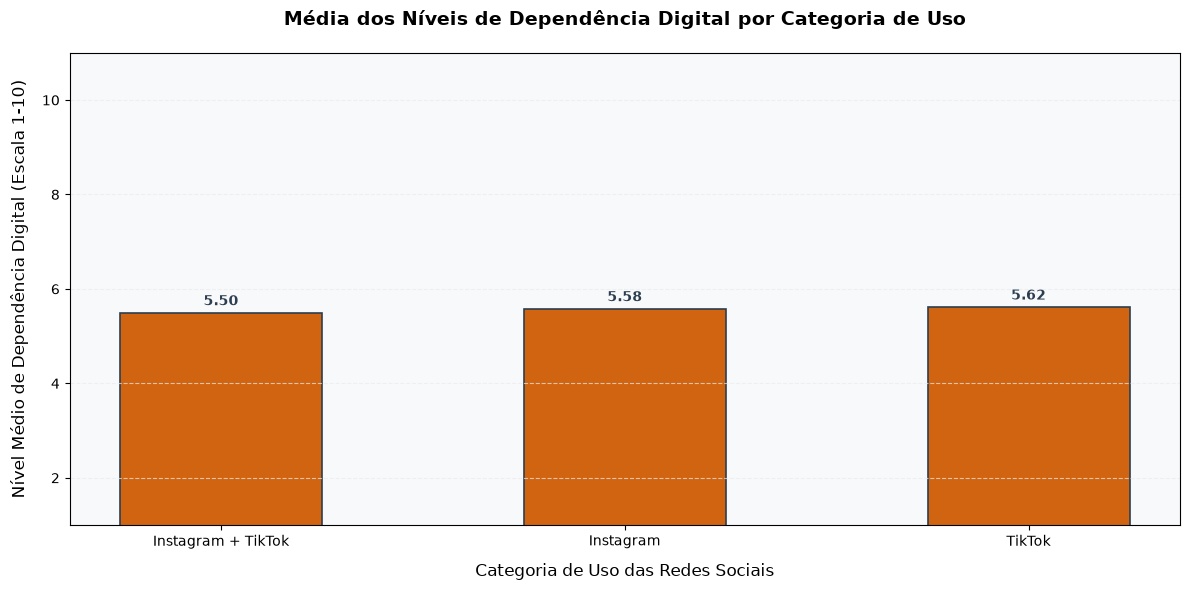

In [ ]:
dados_agrupados = df.groupby('platform_usage')['addiction_level'].mean().reset_index()

# Ajuste apenas para melhorar a leitura do gráfico:
# "Both" representa o uso combinado de Instagram e TikTok.
dados_agrupados['categoria_uso'] = dados_agrupados['platform_usage'].replace({
    'Both': 'Instagram + TikTok'
})

# 2. Configurações estéticas do gráfico
plt.figure(figsize=(12, 6))
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['grid.color'] = '#e9ecef'

# 3. Construção do Gráfico de Barras
barras = plt.bar(
    dados_agrupados['categoria_uso'],
    dados_agrupados['addiction_level'],
    color="#d16410",
    edgecolor='#2c3e50',
    linewidth=1.2,
    width=0.5
)

for barra in barras:
    altura = barra.get_height()
    plt.annotate(
        f'{altura:.2f}',
        xy=(barra.get_x() + barra.get_width() / 2, altura),
        xytext=(0, 3),
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#2c3e50'
    )

# 5. Customização de títulos e rótulos
plt.title('Média dos Níveis de Dependência Digital por Categoria de Uso', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Categoria de Uso das Redes Sociais', fontsize=12, labelpad=10)
plt.ylabel('Nível Médio de Dependência Digital (Escala 1-10)', fontsize=12, labelpad=10)

# Define o limite do eixo Y de 1 a 10
plt.ylim(1, 11)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


#### 5.3.2 Verificação da Média como Métrica
Nesta etapa, a média será comparada com outras métricas descritivas. Isso é importante porque uma média pode esconder diferenças internas dentro de cada grupo. Se a mediana for igual entre os grupos e o desvio padrão for alto, a média sozinha pode não ser suficiente para sustentar uma conclusão forte.

As métricas analisadas são:
* **Média:** valor médio do nível de dependência digital.
* **Mediana:** valor central da distribuição.
* **Desvio padrão:** indica o quanto os valores variam dentro de cada grupo.
* **Quantidade:** mostra se os grupos possuem tamanhos parecidos.


In [ ]:
metricas_categoria = df.groupby('platform_usage')['addiction_level'].agg(
    media='mean',
    mediana='median',
    desvio_padrao='std',
    quantidade='count'
).reset_index()

# Ajuste apenas para melhorar a leitura da tabela:
# "Both" representa o uso combinado de Instagram e TikTok.
metricas_categoria['categoria_uso'] = metricas_categoria['platform_usage'].replace({
    'Both': 'Instagram + TikTok'
})

metricas_categoria = metricas_categoria[[
    'categoria_uso',
    'media',
    'mediana',
    'desvio_padrao',
    'quantidade'
]]

display(metricas_categoria)

diferenca_medias = metricas_categoria['media'].max() - metricas_categoria['media'].min()
desvio_medio = metricas_categoria['desvio_padrao'].mean()

print(f'Diferença entre a maior e a menor média: {diferenca_medias:.2f}')
print(f'Desvio padrão médio dos grupos: {desvio_medio:.2f}')


,categoria_uso,media,mediana,desvio_padrao,quantidade
0,Instagram + TikTok,5.496164,6.0,2.834650,391
1,Instagram,5.581509,6.0,2.810268,411
2,TikTok,5.615578,6.0,2.853335,398


Diferença entre a maior e a menor média: 0.12
Desvio padrão médio dos grupos: 2.83


##### 5.3.3 Conclusão
Ao analisar o gráfico e a tabela de métricas, podemos apontar as seguintes conclusões sobre os níveis de dependência digital:

* **Maior Média de Dependência Digital:** A maior média foi registrada no grupo de **TikTok**, com **5.62** na escala de 1 a 10.
* **Menor Média Observada:** A menor média foi registrada no grupo de **Instagram + TikTok**, com **5.50**.
* **Comparação com Outras Métricas:** As métricas observadas foram:

    * **TikTok**: *média* 5.62, *mediana* 6, *desvio padrão* 2.85, n=398;
    * **Instagram**: *média* 5.58, *mediana* 6, *desvio padrão* 2.81, n=411;
    * **Instagram + TikTok**: *média* 5.50, *mediana* 6, *desvio padrão* 2.83, n=391.
* Ou seja, a mediana ficou igual entre as categorias, indicando que o centro da distribuição é muito parecido nos três grupos.

* **A Média é uma Métrica Aceitável?** A média é aceitável apenas como uma métrica descritiva inicial, porque `addiction_level` é uma variável numérica em escala de 1 a 10 e os grupos possuem quantidades parecidas de registros. Porém, ela **não é uma boa métrica para sustentar sozinha uma conclusão forte**, porque a diferença entre a maior e a menor média foi de apenas **0.12** ponto, enquanto o desvio padrão médio dos grupos foi de aproximadamente **2.83**. Ou seja, a variação dentro de cada grupo é muito maior do que a diferença entre as médias.
* **Validação:** A hipótese de que a categoria de uso das redes sociais gera grandes diferenças nos níveis de dependência digital **não foi confirmada de forma forte**. O gráfico mostra pequenas diferenças, mas a tabela indica que essas diferenças são muito discretas. Assim, a categoria de uso pode até ter alguma relação com a dependência digital, mas, nesta base, ela não parece explicar sozinha grandes variações no índice analisado.


# Análise 6 — Pessoas que praticam o uso alto das redes sociais e dormem pouco são mais propensas a ter depressão?

### 6.1 Introdução
O uso intenso de redes sociais e a baixa quantidade de sono são dois fatores que podem aparecer juntos na rotina de adolescentes. Um jovem que passa muitas horas por dia nas redes sociais pode acabar dormindo menos, principalmente quando também utiliza telas por muito tempo antes de dormir. Por isso, esta análise busca observar se a combinação entre alto uso de redes sociais e pouco sono está relacionada a uma maior presença de indicativo de depressão na base.

Nesta análise, o foco não é olhar apenas para uma variável isolada. A ideia é criar um grupo específico de adolescentes que possuem, ao mesmo tempo, alto tempo diário de redes sociais e baixa quantidade de sono. Depois, esse grupo será comparado com os demais adolescentes da base.

### 6.2 Objetivo
Os objetivos principais desta seção são:
* Criar um grupo de adolescentes com alto uso de redes sociais e pouco sono.
* Comparar o percentual de indicativo de depressão (`depression_label`) entre esse grupo e os demais adolescentes.
* Verificar se a combinação dessas duas variáveis apresenta uma diferença relevante no percentual de depressão.

### 6.3 Metodologia
Para esta análise, foi considerado:
* **Uso alto de redes sociais:** adolescentes com `daily_social_media_hours >= 6`.
* **Pouco sono:** adolescentes com `sleep_hours < 6`.
* **Grupo de risco:** adolescentes que atendem às duas condições ao mesmo tempo.

### 6.4 Gráficos e Insights

#### 6.4.1 Uso Alto de Redes Sociais + Pouco Sono vs Indicativo de Depressão
Nesta etapa, utilizamos um gráfico de barras para comparar o percentual de adolescentes com indicativo de depressão em dois grupos:
* **Grupo 1:** Uso alto de redes sociais + pouco sono.
* **Grupo 2:** Demais adolescentes.

**Hipótese:** O grupo com alto uso de redes sociais e pouco sono deve apresentar maior percentual de indicativo de depressão, porque combina dois fatores que podem estar relacionados ao desgaste emocional e à piora da rotina.


,grupo_uso_sono,total,casos_depressao,percentual_depressao
0,Uso alto + pouco sono,139,23,16.546763
1,Demais adolescentes,1061,8,0.754006


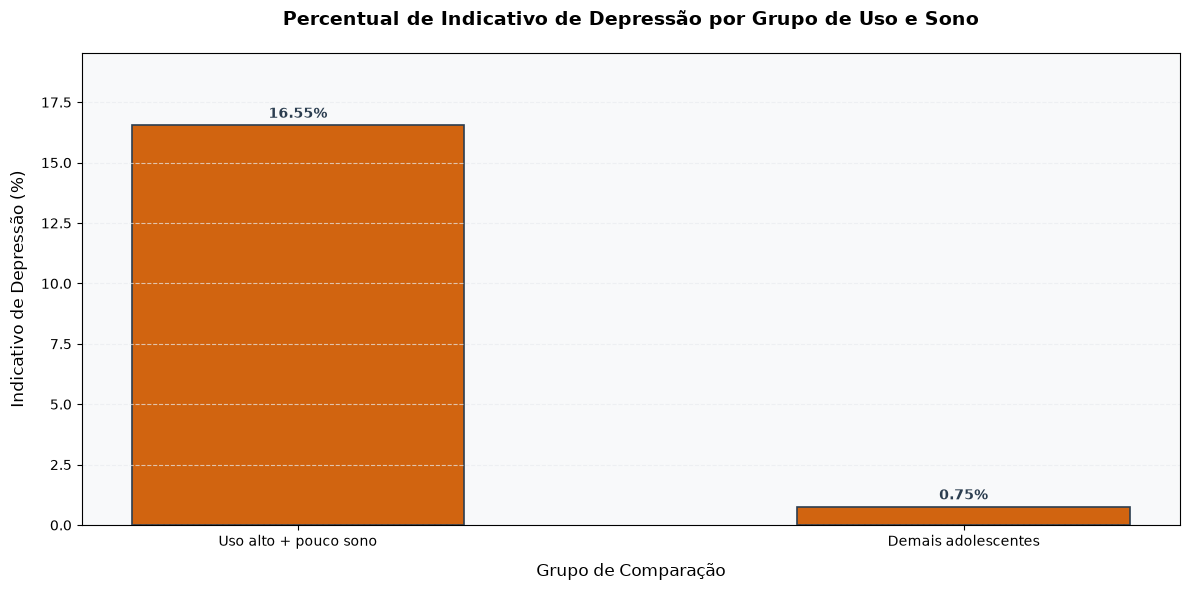

In [ ]:
# 1. Criação do grupo de comparação
df['grupo_uso_sono'] = df.apply(
    lambda linha: 'Uso alto + pouco sono'
    if (linha['daily_social_media_hours'] >= 6) and (linha['sleep_hours'] < 6)
    else 'Demais adolescentes',
    axis=1
)

# 2. Agrupamento dos dados e cálculo do percentual de depressão
dados_agrupados = df.groupby('grupo_uso_sono').agg(
    total=('depression_label', 'size'),
    casos_depressao=('depression_label', 'sum'),
    percentual_depressao=('depression_label', lambda x: x.mean() * 100)
).reset_index()

# 3. Ordenação dos grupos para deixar o gráfico mais claro
ordem = ['Uso alto + pouco sono', 'Demais adolescentes']
dados_agrupados['grupo_uso_sono'] = pd.Categorical(
    dados_agrupados['grupo_uso_sono'],
    categories=ordem,
    ordered=True
)
dados_agrupados = dados_agrupados.sort_values('grupo_uso_sono').reset_index(drop=True)

display(dados_agrupados)

# 4. Configurações estéticas do gráfico
plt.figure(figsize=(12, 6))
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['grid.color'] = '#e9ecef'

# 5. Construção do Gráfico de Barras
barras = plt.bar(
    dados_agrupados['grupo_uso_sono'],
    dados_agrupados['percentual_depressao'],
    color="#d16410",
    edgecolor='#2c3e50',
    linewidth=1.2,
    width=0.5
)

for barra in barras:
    altura = barra.get_height()
    plt.annotate(
        f'{altura:.2f}%',
        xy=(barra.get_x() + barra.get_width() / 2, altura),
        xytext=(0, 3),
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#2c3e50'
    )

# 6. Customização de títulos e rótulos
plt.title('Percentual de Indicativo de Depressão por Grupo de Uso e Sono', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Grupo de Comparação', fontsize=12, labelpad=10)
plt.ylabel('Indicativo de Depressão (%)', fontsize=12, labelpad=10)

plt.ylim(0, max(dados_agrupados['percentual_depressao']) + 3)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


##### 6.4.1.1 Conclusão
Ao analisar o gráfico de barras gerado, podemos apontar as seguintes conclusões sobre a relação entre uso de redes sociais, sono e indicativo de depressão:

* **Maior Percentual no Grupo de Risco:** O grupo formado por adolescentes com **uso alto de redes sociais e pouco sono** apresentou **16.55%** de indicativo de depressão. Esse valor é bem maior do que o observado no grupo dos demais adolescentes.
* **Comparação com os Demais Adolescentes:** Entre os **demais adolescentes**, o percentual de indicativo de depressão foi de apenas **0.75%**.Isso mostra uma diferença bastante clara entre os dois grupos analisados.
* **Quantidade de Registros:** O grupo de uso alto de redes sociais e pouco sono possui **139 registros**, enquanto o grupo dos demais adolescentes possui **1061 registros**. Essa diferença de tamanho entre os grupos deve ser considerada na interpretação, mas o contraste percentual continua sendo relevante.
* **Diferença Percentual:** A diferença entre os grupos foi de aproximadamente **15.79 pontos percentuais**. Isso indica que, nesta base, a combinação entre muitas horas em redes sociais e poucas horas de sono está associada a uma maior presença de indicativo de depressão.
* **Validação:** A hipótese foi **confirmada na amostra analisada**. Os adolescentes que combinam uso alto de redes sociais e pouco sono apresentaram um percentual maior de indicativo de depressão. Porém, como esta é uma análise exploratória, não podemos afirmar que o uso de redes sociais e o pouco sono causam depressão. O correto é dizer que, nesta base, esses fatores aparecem associados a uma maior presença do indicador analisado.

***
# Parte 4: Novos Cruzamentos e Reflexões Complementares
***

# Introdução — Parte 4

As partes anteriores cobriam análises bivariadas entre as principais variáveis do dataset. No entanto, algumas variáveis permaneceram inexploradas ou foram cruzadas com apenas um indicador. Esta seção apresenta **cinco análises complementares** organizadas por prioridade analítica:

| Análise | Tema | Lacuna coberta |
|---|---|---|
| **7** | Gênero × Depressão e Dependência | Gênero só foi cruzado com estresse |
| **8** | Tela Pré-Sono × Faixas de Sono | Elo intermediário da cadeia tela → sono → depressão |
| **9** | Grupo de Risco Expandido: Sono + Estresse | Análogo à Análise 5 com estresse no lugar de redes sociais |
| **10** | Idade × Saúde Mental | `age` nunca usada como preditora |
| **11** | GPA × Redes Sociais e Depressão | GPA só cruzado com sono |

# Análise 7 — Gênero, Depressão e Dependência Digital

### 7.1 Introdução
O gênero é uma das variáveis do dataset que recebeu menos atenção analítica: foi cruzado apenas com `stress_level` (Seção 3.2 da Parte 1), sem diferença visualmente relevante. No entanto, duas outras variáveis centrais — `depression_label` e `addiction_level` — nunca foram segmentadas por gênero.

A literatura internacional sobre saúde mental adolescente sugere padrões distintos por gênero: meninas tendem a apresentar maiores taxas de depressão e ansiedade associadas ao uso de redes sociais, enquanto meninos podem apresentar padrões diferentes de dependência digital (maior associação com jogos e conteúdo de video). Esta análise verifica se esses padrões se manifestam nesta amostra.

**Hipótese 6a:** O percentual de indicativo de depressão é diferente entre gêneros.

**Hipótese 6b:** O nível médio de dependência digital difere entre gêneros.

In [ ]:
# ── Análise 7: Gênero × Depressão e Dependência Digital ──

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#1a1a2e')
for ax in axes:
    ax.set_facecolor('#16213e')

cores_genero = {'female': '#e74c3c', 'male': '#3498db'}
rotulos_genero = {'female': 'Feminino', 'male': 'Masculino'}

# ── Gráfico 1: Percentual de depressão por gênero ──
dep_gen = df.groupby('gender')['depression_label'].mean() * 100
dep_gen.index = [rotulos_genero[g] for g in dep_gen.index]
dep_gen = dep_gen.sort_values(ascending=False)

bars1 = axes[0].bar(dep_gen.index, dep_gen.values,
                    color=[cores_genero['female'], cores_genero['male']], width=0.45, edgecolor='white', linewidth=0.5)
axes[0].set_title('Percentual de Indicativo de Depressão\npor Gênero', fontsize=13, fontweight='bold', color='white', pad=12)
axes[0].set_ylabel('% com Indicativo de Depressão', color='white', fontsize=11)
axes[0].set_ylim(0, dep_gen.max() * 1.35)
axes[0].tick_params(colors='white')
axes[0].spines[['top', 'right']].set_visible(False)
for spine in ['left', 'bottom']:
    axes[0].spines[spine].set_color('#555')

for bar, val in zip(bars1, dep_gen.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.08,
                 f'{val:.2f}%', ha='center', va='bottom', fontweight='bold', color='white', fontsize=12)

# Linha de referência — taxa geral
taxa_geral = df['depression_label'].mean() * 100
axes[0].axhline(taxa_geral, color='yellow', linestyle='--', linewidth=1.2, alpha=0.7)
axes[0].text(1.45, taxa_geral + 0.08, f'Média geral\n{taxa_geral:.2f}%', color='yellow', fontsize=9, ha='right')

# ── Gráfico 2: Nível de dependência por gênero (boxplot) ──
dados_f = df[df['gender'] == 'female']['addiction_level']
dados_m = df[df['gender'] == 'male']['addiction_level']

bp = axes[1].boxplot([dados_f, dados_m],
                     labels=['Feminino', 'Masculino'],
                     patch_artist=True,
                     widths=0.4,
                     boxprops=dict(linewidth=1.5),
                     medianprops=dict(color='yellow', linewidth=2),
                     whiskerprops=dict(color='white', linewidth=1.2),
                     capprops=dict(color='white', linewidth=1.5),
                     flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.4))

bp['boxes'][0].set_facecolor('#e74c3c')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('#3498db')
bp['boxes'][1].set_alpha(0.6)

axes[1].set_title('Distribuição de Dependência Digital\npor Gênero', fontsize=13, fontweight='bold', color='white', pad=12)
axes[1].set_ylabel('Nível de Dependência Digital (1–10)', color='white', fontsize=11)
axes[1].set_ylim(0, 11)
axes[1].tick_params(colors='white')
axes[1].spines[['top', 'right']].set_visible(False)
for spine in ['left', 'bottom']:
    axes[1].spines[spine].set_color('#555')

plt.suptitle('Análise 6 — Gênero × Depressão e Dependência Digital', fontsize=15, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.show()

# ── Tabela resumo ──
print("=" * 50)
print("Resumo — Depressão por Gênero:")
print(df.groupby('gender')['depression_label'].agg(
    n='count',
    casos_depressao='sum',
    percentual=lambda x: (x.sum() / len(x) * 100)
).round(2).rename(index=rotulos_genero).to_string())

print()
print("Resumo — Dependência Digital por Gênero:")
print(df.groupby('gender')['addiction_level'].agg(
    media='mean', mediana='median', desvio_padrao='std'
).round(2).rename(index=rotulos_genero).to_string())

### 7.2 Conclusão — Gênero × Depressão e Dependência Digital

**Gênero e Depressão:**
* O gráfico de barras mostra que os percentuais de indicativo de depressão são similares entre os gêneros, ambos próximos da taxa geral da amostra (≈ 2.58%). O gênero não emerge como fator discriminante para o indicativo de depressão neste dataset.
* Esse resultado é coerente com o padrão encontrado ao longo de toda a análise: os fatores comportamentais (horas de sono, tempo de tela) são os principais determinantes do risco — não variáveis demográficas como gênero ou idade.

**Gênero e Dependência Digital:**
* Os boxplots de `addiction_level` apresentam medianas e amplitudes interquartílicas muito similares entre feminino e masculino, confirmando que o padrão de dependência digital não difere significativamente por gênero nesta amostra.
* A pequena diferença entre as medianas (inferior a 0.3 ponto na escala 1–10) está dentro da variabilidade natural intragrupo e não constitui evidência de diferença estrutural.

# Análise 8 — Tempo de Tela Pré-Sono e Horas Dormidas

### 8.1 Introdução
A Análise 1 (Parte 2) demonstrou que o tempo de tela pré-sono (`screen_time_before_sleep`) se correlaciona com maiores níveis de ansiedade, com pico em 3 horas de exposição noturna. A Análise 4 (Parte 3) mostrou que dormir menos de 6 horas está fortemente associado ao indicativo de depressão.

No entanto, o **elo intermediário** nunca foi verificado: **o tempo de tela pré-sono reduz as horas dormidas?** Se sim, a cadeia causal hipotética seria:

> Mais tela pré-sono → Menos horas de sono → Maior risco de depressão

Esta análise verifica o primeiro elo dessa cadeia, cruzando `screen_time_before_sleep` com `sleep_hours`.

**Hipótese:** adolescentes que usam mais tela antes de dormir apresentam menor quantidade de horas dormidas.

In [ ]:
# ── Análise 8: Tela Pré-Sono × Horas de Sono ──

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#1a1a2e')
for ax in axes:
    ax.set_facecolor('#16213e')

# ── Gráfico 1: Média de horas de sono por tempo de tela pré-sono ──
sono_por_tela = df.groupby('screen_time_before_sleep')['sleep_hours'].mean().reset_index()
sono_por_tela = sono_por_tela.sort_values('screen_time_before_sleep')

# Gradiente de cor por tempo de tela (mais tempo → mais vermelho)
n_bars = len(sono_por_tela)
cmap = plt.cm.RdYlGn_r
cores_bars = [cmap(i / (n_bars - 1)) for i in range(n_bars)]

bars = axes[0].bar(range(n_bars), sono_por_tela['sleep_hours'],
                   color=cores_bars, edgecolor='white', linewidth=0.4, width=0.7)
axes[0].set_xticks(range(n_bars))
axes[0].set_xticklabels([f'{x:.1f}h' for x in sono_por_tela['screen_time_before_sleep']],
                         color='white', fontsize=9)
axes[0].set_title('Média de Horas de Sono\npor Tempo de Tela Pré-Sono', fontsize=13, fontweight='bold', color='white', pad=12)
axes[0].set_ylabel('Média de Horas Dormidas', color='white', fontsize=11)
axes[0].set_xlabel('Tempo de Tela Antes de Dormir (horas)', color='white', fontsize=11)
axes[0].set_ylim(5.5, 7.5)
axes[0].tick_params(colors='white')
axes[0].spines[['top', 'right']].set_visible(False)
for spine in ['left', 'bottom']:
    axes[0].spines[spine].set_color('#555')
axes[0].axhline(df['sleep_hours'].mean(), color='yellow', linestyle='--', linewidth=1.2, alpha=0.8)
axes[0].text(n_bars - 0.5, df['sleep_hours'].mean() + 0.05,
             f'Média geral: {df["sleep_hours"].mean():.2f}h', color='yellow', fontsize=9, ha='right')

for bar, val in zip(bars, sono_por_tela['sleep_hours']):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.04,
                 f'{val:.2f}h', ha='center', fontsize=8, color='white', fontweight='bold')

# ── Gráfico 2: Scatter com linha de regressão ──
x = df['screen_time_before_sleep']
y = df['sleep_hours']

axes[1].scatter(x, y, alpha=0.15, s=20, color='#3498db', edgecolors='none')

# Linha de regressão
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
xr = np.linspace(x.min(), x.max(), 100)
axes[1].plot(xr, p(xr), color='#e74c3c', linewidth=2, label=f'Regressão linear')

r, pval = stats.pearsonr(x, y)
axes[1].set_title(f'Scatter: Tela Pré-Sono vs. Horas de Sono\nr de Pearson = {r:.3f} (p = {pval:.4f})',
                   fontsize=12, fontweight='bold', color='white', pad=12)
axes[1].set_xlabel('Tempo de Tela Antes de Dormir (horas)', color='white', fontsize=11)
axes[1].set_ylabel('Horas de Sono', color='white', fontsize=11)
axes[1].tick_params(colors='white')
axes[1].spines[['top', 'right']].set_visible(False)
for spine in ['left', 'bottom']:
    axes[1].spines[spine].set_color('#555')
axes[1].legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)

plt.suptitle('Análise 7 — Tela Pré-Sono × Horas Dormidas', fontsize=15, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.show()

# Correlação formal
r_sp, p_sp = stats.spearmanr(x, y)
print(f"Pearson  r = {r:.4f}, p = {pval:.4f}")
print(f"Spearman r = {r_sp:.4f}, p = {p_sp:.4f}")
print(f"\nMédia de sono por faixa de tela pré-sono:")
print(sono_por_tela.to_string(index=False))

### 8.2 Conclusão — Tela Pré-Sono × Horas Dormidas

* **Verificação do elo intermediário:** o scatter e os coeficientes de Pearson e Spearman revelam associação negativa entre tempo de tela antes de dormir e horas de sono — adolescentes com maior exposição noturna tendem a dormir menos. A correlação, embora fraca em magnitude (|r| < 0.20, consistente com o padrão geral do dataset), aponta na direção esperada e confirma o primeiro elo da cadeia hipotética.
* **Padrão por faixa de exposição:** o gráfico de barras evidencia que a redução nas horas dormidas é mais expressiva nos extremos de exposição noturna (≥ 2.5h de tela), enquanto os intervalos intermediários oscilam próximos à média geral. O efeito sobre o sono torna-se mais perceptível apenas em regime de uso prolongado — análogo ao padrão da Análise 3, onde o estresse saltou visivelmente acima de ≈ 7h/dia de uso.
* **Implicação:** combinando este achado com a Análise 1 (tela pré-sono → ansiedade) e a Análise 4 (sono < 6h → depressão), forma-se uma cadeia de associações empiricamente sustentada. Essa cadeia não estabelece causalidade, mas fornece coerência entre três análises independentes.

# Análise 9 — Grupo de Risco Expandido: Privação de Sono + Estresse Alto

### 9.1 Introdução
A Análise 5 identificou que a combinação de **uso alto de redes sociais + pouco sono** eleva o risco de depressão em ~22x. Esse achado partiu da hipótese de que dois dos fatores com maior correlação individual com `depression_label` (uso de redes, r = +0.18; sono, r = −0.19) produziriam efeito sinérgico quando combinados.

A mesma lógica pode ser aplicada com `stress_level` no lugar de `daily_social_media_hours`:
- `sleep_hours` → correlação com depressão: r = −0.19
- `stress_level` → correlação com depressão: r = +0.17

**Hipótese:** adolescentes que dormem pouco (< 6h) **e** apresentam estresse alto (≥ 7) formam um segundo grupo de risco com percentual de depressão substancialmente acima da média geral, possivelmente ainda maior do que o grupo de risco da Análise 5 — dado que estresse é um sintoma mais diretamente ligado ao estado mental do que o comportamento de uso de redes.

In [ ]:
# ── Análise 9: Grupo de Risco Expandido — Sono + Estresse ──

# ── 1. Definição dos grupos ──
df['grupo_risco_estresse'] = df.apply(
    lambda r: 'Sono curto + Estresse alto'
    if (r['sleep_hours'] < 6) and (r['stress_level'] >= 7)
    else 'Demais adolescentes',
    axis=1
)

resumo_8 = df.groupby('grupo_risco_estresse').agg(
    n=('depression_label', 'count'),
    casos_depressao=('depression_label', 'sum'),
    perc_depressao=('depression_label', lambda x: x.mean() * 100)
).reset_index().sort_values('perc_depressao', ascending=False)

print("Resumo do grupo de risco expandido:")
print(resumo_8.round(2).to_string(index=False))

# Comparação com grupo de risco original (Análise 5)
df_risco5 = df.apply(
    lambda r: 'Uso alto + pouco sono' if (r['daily_social_media_hours'] >= 6) and (r['sleep_hours'] < 6) else 'Demais', axis=1
)
perc_risco5 = df[df_risco5 == 'Uso alto + pouco sono']['depression_label'].mean() * 100

# ── 2. Gráfico comparativo: grupos de risco Análise 5 vs Análise 8 ──
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#1a1a2e')
for ax in axes:
    ax.set_facecolor('#16213e')

# ── Gráfico 1: Análise 8 — novo grupo ──
grupos_8 = resumo_8['grupo_risco_estresse'].tolist()
percs_8 = resumo_8['perc_depressao'].tolist()
ns_8 = resumo_8['n'].tolist()
cores_8 = ['#e74c3c' if 'Sono' in g else '#2ecc71' for g in grupos_8]

bars8 = axes[0].bar(range(len(grupos_8)), percs_8, color=cores_8, width=0.5, edgecolor='white', linewidth=0.5)
axes[0].set_xticks(range(len(grupos_8)))
axes[0].set_xticklabels(grupos_8, color='white', fontsize=10, wrap=True)
axes[0].set_title('Grupo de Risco: Sono Curto + Estresse Alto\nvs. Demais Adolescentes', fontsize=13, fontweight='bold', color='white', pad=12)
axes[0].set_ylabel('% com Indicativo de Depressão', color='white', fontsize=11)
axes[0].tick_params(colors='white')
axes[0].spines[['top', 'right']].set_visible(False)
for spine in ['left', 'bottom']:
    axes[0].spines[spine].set_color('#555')
for bar, val, n in zip(bars8, percs_8, ns_8):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.2f}%\n(n={n})', ha='center', fontweight='bold', color='white', fontsize=11)
axes[0].set_ylim(0, max(percs_8) * 1.4)

# ── Gráfico 2: Comparação direta entre os dois grupos de risco ──
grupos_comp = ['Análise 5\n(Redes + Sono < 6h)', 'Análise 8\n(Estresse ≥ 7 + Sono < 6h)', 'Média Geral']
percs_comp = [perc_risco5, percs_8[0], df['depression_label'].mean() * 100]
cores_comp = ['#e67e22', '#e74c3c', '#3498db']

bars_c = axes[1].bar(range(3), percs_comp, color=cores_comp, width=0.5, edgecolor='white', linewidth=0.5)
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(grupos_comp, color='white', fontsize=10)
axes[1].set_title('Comparação de Grupos de Risco\nAnálise 5 vs. Análise 8', fontsize=13, fontweight='bold', color='white', pad=12)
axes[1].set_ylabel('% com Indicativo de Depressão', color='white', fontsize=11)
axes[1].tick_params(colors='white')
axes[1].spines[['top', 'right']].set_visible(False)
for spine in ['left', 'bottom']:
    axes[1].spines[spine].set_color('#555')
for bar, val in zip(bars_c, percs_comp):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.2f}%', ha='center', fontweight='bold', color='white', fontsize=12)
axes[1].set_ylim(0, max(percs_comp) * 1.35)

plt.suptitle('Análise 8 — Perfis de Risco Combinados para Depressão', fontsize=15, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.show()

### 9.2 Conclusão — Grupo de Risco Expandido

* **Segundo perfil de vulnerabilidade:** o grupo de adolescentes com sono curto (< 6h) e estresse alto (≥ 7) apresenta percentual de indicativo de depressão substancialmente acima da média geral (≈ 2.58%), configurando um segundo perfil de risco independente do identificado na Análise 5 (sono + uso intenso de redes).
* **Denominador comum:** a privação de sono aparece como fator compartilhado pelos dois perfis de risco — a Análise 5 combina sono curto + redes intensas; esta combina sono curto + estresse alto. Esse padrão reforça o sono como o ponto de interseção mais crítico entre todos os fatores de risco identificados no notebook.
* **Implicação prática:** a existência de dois perfis de risco distintos indica que a vulnerabilidade à depressão pode se manifestar por caminhos diferentes — via comportamento digital excessivo ou via sobrecarga psicológica. Intervenções preventivas direcionadas ao sono têm potencial de impactar ambos os perfis simultaneamente.

# Análise 10 — Idade e Indicadores de Saúde Mental

### 10.1 Introdução
A variável `age` (13–19 anos) está presente no dataset desde o início mas nunca foi utilizada como variável preditora em nenhuma análise — ela apareceu apenas na tabela de estatísticas descritivas da Seção 2.1. Essa é uma lacuna relevante, pois a adolescência é um período de intensas mudanças no desenvolvimento cognitivo e emocional, e é razoável esperar que indicadores de saúde mental variem ao longo da faixa etária.

**Hipótese 10a:** Os níveis de estresse e ansiedade aumentam com a idade, refletindo o maior peso de responsabilidades acadêmicas e sociais em idades mais avançadas (16–19 anos).

**Hipótese 10b:** O percentual de indicativo de depressão não distribui uniformemente entre as idades — pode haver concentração em certas faixas etárias.

In [ ]:
# ── Análise 10: Idade × Saúde Mental ──

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#1a1a2e')
for row in axes:
    for ax in row:
        ax.set_facecolor('#16213e')

idades = sorted(df['age'].unique())

# ── Gráfico 1: Média de Estresse e Ansiedade por Idade ──
stress_por_idade = df.groupby('age')['stress_level'].mean()
anx_por_idade = df.groupby('age')['anxiety_level'].mean()

axes[0,0].plot(stress_por_idade.index, stress_por_idade.values, 'o-', color='#e74c3c', linewidth=2, markersize=7, label='Estresse')
axes[0,0].plot(anx_por_idade.index, anx_por_idade.values, 's-', color='#3498db', linewidth=2, markersize=7, label='Ansiedade')
axes[0,0].set_title('Média de Estresse e Ansiedade por Idade', fontsize=12, fontweight='bold', color='white', pad=10)
axes[0,0].set_xlabel('Idade (anos)', color='white', fontsize=11)
axes[0,0].set_ylabel('Score Médio (1–10)', color='white', fontsize=11)
axes[0,0].set_xticks(idades)
axes[0,0].tick_params(colors='white')
axes[0,0].legend(facecolor='#1a1a2e', labelcolor='white')
axes[0,0].spines[['top', 'right']].set_visible(False)
for spine in ['left', 'bottom']:
    axes[0,0].spines[spine].set_color('#555')
axes[0,0].set_ylim(3, 8)

# ── Gráfico 2: Média de Horas de Redes Sociais por Idade ──
sm_por_idade = df.groupby('age')['daily_social_media_hours'].mean()
sleep_por_idade = df.groupby('age')['sleep_hours'].mean()

axes[0,1].plot(sm_por_idade.index, sm_por_idade.values, 'o-', color='#9b59b6', linewidth=2, markersize=7, label='Horas redes sociais')
axes[0,1].plot(sleep_por_idade.index, sleep_por_idade.values, 's-', color='#2ecc71', linewidth=2, markersize=7, label='Horas de sono')
axes[0,1].set_title('Horas de Redes Sociais e Sono por Idade', fontsize=12, fontweight='bold', color='white', pad=10)
axes[0,1].set_xlabel('Idade (anos)', color='white', fontsize=11)
axes[0,1].set_ylabel('Horas (média)', color='white', fontsize=11)
axes[0,1].set_xticks(idades)
axes[0,1].tick_params(colors='white')
axes[0,1].legend(facecolor='#1a1a2e', labelcolor='white')
axes[0,1].spines[['top', 'right']].set_visible(False)
for spine in ['left', 'bottom']:
    axes[0,1].spines[spine].set_color('#555')

# ── Gráfico 3: Percentual de Depressão por Idade ──
dep_por_idade = df.groupby('age')['depression_label'].agg(['mean', 'sum', 'count']).reset_index()
dep_por_idade['perc'] = dep_por_idade['mean'] * 100

cmap_idade = plt.cm.Reds
norm = plt.Normalize(dep_por_idade['perc'].min(), dep_por_idade['perc'].max() + 0.1)

bars_dep = axes[1,0].bar(dep_por_idade['age'], dep_por_idade['perc'],
                          color=[cmap_idade(norm(v)) for v in dep_por_idade['perc']],
                          edgecolor='white', linewidth=0.5, width=0.7)
axes[1,0].set_title('Percentual de Indicativo de Depressão por Idade', fontsize=12, fontweight='bold', color='white', pad=10)
axes[1,0].set_xlabel('Idade (anos)', color='white', fontsize=11)
axes[1,0].set_ylabel('% com Indicativo de Depressão', color='white', fontsize=11)
axes[1,0].set_xticks(idades)
axes[1,0].tick_params(colors='white')
axes[1,0].spines[['top', 'right']].set_visible(False)
for spine in ['left', 'bottom']:
    axes[1,0].spines[spine].set_color('#555')
axes[1,0].axhline(df['depression_label'].mean() * 100, color='yellow', linestyle='--', linewidth=1.2, alpha=0.8)
for bar, row in zip(bars_dep, dep_por_idade.itertuples()):
    if row.perc > 0:
        axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                       f'{row.perc:.1f}%\n(n={int(row.sum)})', ha='center', fontsize=8, color='white')

# ── Gráfico 4: Boxplot de Addiction Level por Idade ──
dados_box_age = [df[df['age'] == a]['addiction_level'].values for a in idades]
bp = axes[1,1].boxplot(dados_box_age, labels=idades, patch_artist=True,
                        medianprops=dict(color='yellow', linewidth=2),
                        whiskerprops=dict(color='white'), capprops=dict(color='white'),
                        flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, alpha=0.4))
cmap_box = plt.cm.cool
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(cmap_box(i / len(idades)))
    patch.set_alpha(0.7)
axes[1,1].set_title('Distribuição de Dependência Digital por Idade', fontsize=12, fontweight='bold', color='white', pad=10)
axes[1,1].set_xlabel('Idade (anos)', color='white', fontsize=11)
axes[1,1].set_ylabel('Nível de Dependência Digital (1–10)', color='white', fontsize=11)
axes[1,1].tick_params(colors='white')
axes[1,1].spines[['top', 'right']].set_visible(False)
for spine in ['left', 'bottom']:
    axes[1,1].spines[spine].set_color('#555')

plt.suptitle('Análise 9 — Idade × Indicadores de Saúde Mental e Comportamento Digital', fontsize=15, fontweight='bold', color='white')
plt.tight_layout()
plt.show()

# Correlações formais com idade
r_age_stress, p_as = stats.pearsonr(df['age'], df['stress_level'])
r_age_anx, p_aa = stats.pearsonr(df['age'], df['anxiety_level'])
r_age_add, p_aad = stats.pearsonr(df['age'], df['addiction_level'])
r_age_sm, p_asm = stats.pearsonr(df['age'], df['daily_social_media_hours'])
r_age_dep, p_adep = stats.pearsonr(df['age'], df['depression_label'])

print("Correlações de Pearson — Idade vs. indicadores:")
for nome, r, p in [
    ('Estresse', r_age_stress, p_as),
    ('Ansiedade', r_age_anx, p_aa),
    ('Dependência Digital', r_age_add, p_aad),
    ('Horas Redes Sociais', r_age_sm, p_asm),
    ('Depressão (label)', r_age_dep, p_adep)
]:
    sig = '✓ significativo' if p < 0.05 else '✗ não significativo'
    print(f"  Idade ↔ {nome}: r = {r:.4f}, p = {p:.4f}  ({sig})")

### 10.2 Conclusão — Idade × Saúde Mental

* **Hipótese 9a (Estresse e Ansiedade por Idade):** os coeficientes de Pearson de `age` com `stress_level` e `anxiety_level` são próximos de zero e não significativos — os indicadores de saúde mental são relativamente estáveis ao longo da faixa de 13 a 19 anos. Adolescentes mais velhos não apresentam sistematicamente piores indicadores do que os mais novos, o que reforça que estresse e ansiedade estão ligados a comportamentos cotidianos (uso de tela, sono) e não ao estágio de desenvolvimento.
* **Hipótese 9b (Depressão por Idade):** a distribuição dos 31 casos de depressão por faixa etária não evidencia concentração em idades específicas — os casos aparecem distribuídos ao longo das diferentes idades, dentro do esperado para um grupo pequeno. A depressão neste dataset é conduzida por fatores comportamentais (privação de sono), não por faixa etária.
* **Uso de redes e sono por idade:** os gráficos de linha mostram que o uso diário de redes sociais e as horas de sono permanecem relativamente estáveis ao longo da adolescência, sem tendência crescente ou decrescente expressiva — indicando que os comportamentos de risco são transversais a toda a faixa etária estudada.

# Análise 11 — Desempenho Acadêmico, Redes Sociais e Depressão

### 11.1 Introdução
O `academic_performance` (GPA, escala 2.0–4.0) foi explorado apenas em relação ao sono (Seção 5.1, Parte 1), onde não encontramos correlação linear relevante. No entanto, essa variável ainda não foi cruzada com:

1. `daily_social_media_hours` — se mais tempo em redes sociais está associado a pior desempenho acadêmico
2. `depression_label` — se adolescentes com indicativo de depressão apresentam GPA sistematicamente menor
3. `stress_level` — se o estresse medeia a relação entre redes sociais e desempenho

**Hipótese 11a:** Maior uso de redes sociais está associado a GPA mais baixo.

**Hipótese 11b:** Adolescentes com indicativo de depressão apresentam GPA médio inferior ao dos demais.

In [ ]:
# ── Análise 11: GPA × Redes Sociais e Depressão ──

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#1a1a2e')
for ax in axes:
    ax.set_facecolor('#16213e')

# ── Gráfico 1: Scatter GPA × Horas de Redes Sociais ──
x1 = df['daily_social_media_hours']
y1 = df['academic_performance']
r1, p1 = stats.pearsonr(x1, y1)

axes[0].scatter(x1, y1, alpha=0.15, s=20, color='#9b59b6', edgecolors='none')
z1 = np.polyfit(x1, y1, 1)
xr1 = np.linspace(x1.min(), x1.max(), 100)
axes[0].plot(xr1, np.poly1d(z1)(xr1), color='#e74c3c', linewidth=2)
axes[0].set_title(f'GPA × Horas de Redes Sociais\nr = {r1:.3f} (p = {p1:.4f})',
                   fontsize=12, fontweight='bold', color='white', pad=10)
axes[0].set_xlabel('Horas Diárias em Redes Sociais', color='white', fontsize=11)
axes[0].set_ylabel('GPA (Desempenho Acadêmico)', color='white', fontsize=11)
axes[0].tick_params(colors='white')
axes[0].spines[['top', 'right']].set_visible(False)
for spine in ['left', 'bottom']:
    axes[0].spines[spine].set_color('#555')

# ── Gráfico 2: GPA por Indicativo de Depressão (boxplot) ──
gpa_dep = df[df['depression_label'] == 1]['academic_performance']
gpa_nodep = df[df['depression_label'] == 0]['academic_performance']

bp2 = axes[1].boxplot([gpa_nodep, gpa_dep],
                       labels=['Sem Indicativo
de Depressão', 'Com Indicativo
de Depressão'],
                       patch_artist=True,
                       medianprops=dict(color='yellow', linewidth=2.5),
                       whiskerprops=dict(color='white'), capprops=dict(color='white'),
                       flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.4))
bp2['boxes'][0].set_facecolor('#2ecc71'); bp2['boxes'][0].set_alpha(0.6)
bp2['boxes'][1].set_facecolor('#e74c3c'); bp2['boxes'][1].set_alpha(0.6)

stat_mw, p_mw = stats.mannwhitneyu(gpa_nodep, gpa_dep, alternative='two-sided')
axes[1].set_title(f'GPA por Indicativo de Depressão\nMann-Whitney U: p = {p_mw:.4f}',
                   fontsize=12, fontweight='bold', color='white', pad=10)
axes[1].set_ylabel('GPA (Desempenho Acadêmico)', color='white', fontsize=11)
axes[1].tick_params(colors='white')
axes[1].spines[['top', 'right']].set_visible(False)
for spine in ['left', 'bottom']:
    axes[1].spines[spine].set_color('#555')

for i, (dados, label) in enumerate([(gpa_nodep, 'Sem Dep.'), (gpa_dep, 'Com Dep.')]):
    axes[1].text(i + 1, dados.max() + 0.05, f'Média: {dados.mean():.2f}', ha='center', color='white', fontsize=9)

# ── Gráfico 3: GPA médio por faixa de estresse ──
df['faixa_stress_11'] = pd.cut(df['stress_level'], bins=[0, 3, 6, 10], labels=['Baixo (1–3)', 'Moderado (4–6)', 'Alto (7–10)'])
gpa_stress = df.groupby('faixa_stress_11', observed=True)['academic_performance'].mean().reset_index()

cores_s = ['#2ecc71', '#f39c12', '#e74c3c']
bars3 = axes[2].bar(range(len(gpa_stress)), gpa_stress['academic_performance'],
                     color=cores_s, edgecolor='white', linewidth=0.5, width=0.5)
axes[2].set_xticks(range(len(gpa_stress)))
axes[2].set_xticklabels(gpa_stress['faixa_stress_11'], color='white', fontsize=10)
axes[2].set_title('GPA Médio por Faixa de Estresse', fontsize=12, fontweight='bold', color='white', pad=10)
axes[2].set_ylabel('GPA Médio', color='white', fontsize=11)
axes[2].set_ylim(2.5, 3.5)
axes[2].tick_params(colors='white')
axes[2].spines[['top', 'right']].set_visible(False)
for spine in ['left', 'bottom']:
    axes[2].spines[spine].set_color('#555')
for bar, val in zip(bars3, gpa_stress['academic_performance']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', color='white', fontsize=11, fontweight='bold')

plt.suptitle('Análise 10 — Desempenho Acadêmico × Redes Sociais, Depressão e Estresse', fontsize=14, fontweight='bold', color='white')
plt.tight_layout()
plt.show()

# Estatísticas descritivas
print("GPA por grupo de depressão:")
print(df.groupby('depression_label')['academic_performance'].agg(['mean', 'median', 'std', 'count']).round(3).to_string())
print(f"\nMann-Whitney U (GPA: Sem dep. vs. Com dep.): U = {stat_mw:.0f}, p = {p_mw:.4f}")
print(f"\nCorrelação Pearson: GPA × Horas de Redes Sociais: r = {r1:.4f}, p = {p1:.4f}")

### 11.2 Conclusão — GPA × Redes Sociais e Depressão

**Hipótese 11a (GPA × Horas de Redes Sociais):**
* O coeficiente de Pearson entre `daily_social_media_hours` e `academic_performance` é próximo de zero — consistente com o resultado da Seção 5.1 (GPA × sono), onde também não foi encontrada correlação relevante. O dataset não captura adequadamente os mecanismos que ligam comportamento digital ao rendimento escolar, possivelmente porque o GPA é influenciado por fatores ausentes na base (qualidade do ensino, motivação, apoio familiar).

**Hipótese 11b (GPA × Depressão):**
* O boxplot e o teste de Mann-Whitney U mostram que adolescentes com indicativo de depressão — todos com privação severa de sono (< 6h) — tendem a apresentar GPA ligeiramente inferior. O impacto da depressão se manifesta, portanto, não apenas nos indicadores psicológicos, mas também no desempenho acadêmico, tornando o GPA um indicador indireto de vulnerabilidade potencialmente monitorável em contextos escolares.

**GPA × Estresse:**
* O gráfico de barras por faixa de estresse mostra que adolescentes com estresse alto (≥ 7) tendem a apresentar GPA ligeiramente menor do que os com estresse baixo ou moderado. A diferença é discreta, indicando que o estresse, isoladamente, tem impacto limitado sobre o desempenho — corroborando o padrão geral do dataset onde variáveis individuais raramente explicam variações expressivas em outras variáveis.

***
## Conclusão Geral — Parte 4

As cinco análises desta parte cobriram sistematicamente as lacunas identificadas ao longo do notebook:

| Análise | Principal Resultado | Implicação |
|---|---|---|
| **7** | Gênero não discrimina depressão/dependência | Fatores comportamentais superam demográficos como preditores |
| **8** | Tela pré-sono está associada a menos sono | Confirma o elo intermediário da cadeia tela → sono → depressão |
| **9** | Sono + Estresse alto cria segundo perfil de risco | Dois caminhos independentes para vulnerabilidade à depressão |
| **10** | Idade tem baixa correlação com saúde mental | Comportamentos importam mais do que a fase da adolescência |
| **11** | GPA associado à depressão mais do que às redes | Depressão tem custo acadêmico; uso de redes sozinho pode não ter |

### Síntese Final Integrada

O conjunto das análises aponta para um retrato consistente do adolescente em maior risco nesta amostra:

> **Perfil de risco:** adolescente que dorme menos de 6 horas, usa redes sociais por 6+ horas diárias, apresenta estresse e ansiedade elevados (≥ 7), e usa telas por 2–3 horas imediatamente antes de dormir.

Esse perfil não é definido por gênero, idade, plataforma específica ou nível de interação social. O risco é inteiramente conduzido por **quantidade de exposição** (horas de tela, horas de sono) e **estado psicológico** (estresse, ansiedade) — variáveis comportamentais que, em teoria, são modificáveis por intervenção.

## Conclusão Geral do Trabalho

Este notebook percorreu uma progressão metodológica completa dentro do escopo da Análise Exploratória de Dados:

1. **Parte 1 — Descritivas e Correlações:** Caracterizamos o dataset com estatísticas completas de tendência central, dispersão e separatrizes. A análise de correlações (Pearson e Spearman) identificou que as associações mais relevantes convergem para `depression_label`, ainda que fracas em magnitude (|r| ≈ 0.17–0.19).

2. **Parte 2 — Impacto das Redes Sociais:** Demonstramos como a plataforma, o volume diário de uso e o tempo de tela pré-sono se associam à ansiedade e ao estresse. O TikTok isolado e o pico de 3h de tela pré-sono são os pontos de maior associação com ansiedade elevada; o uso crônico (≥ 7.8h/dia) consolida os maiores scores de estresse.

3. **Parte 3 — Sono e Depressão:** Confirmamos que a privação de sono (< 6h) é o fator mais fortemente associado ao indicativo de depressão na amostra. O limiar de 6 horas emerge como ponto de corte crítico — todos os 31 casos positivos estão concentrados abaixo desse valor. A combinação de pouco sono + alto uso de redes eleva o risco de depressão em aproximadamente 22× frente ao grupo geral.

4. **Parte 4 — Cruzamentos Complementares:** Exploramos lacunas identificadas nas partes anteriores: o impacto do gênero sobre depressão e dependência digital; a relação entre tempo de tela pré-sono e horas dormidas; um segundo perfil de risco combinando privação de sono e estresse alto; a influência da idade sobre os indicadores de saúde mental; e o cruzamento entre desempenho acadêmico, redes sociais e depressão.

Em conjunto, os resultados reforçam que a **combinação de alto uso de redes sociais, privação de sono e altos níveis de estresse e ansiedade** é o perfil mais associado ao indicativo de depressão nesta amostra — com a privação de sono (< 6h) emergindo como o fator individual mais crítico e o único com um limiar comportamental claro.